In [ ]:
!pip install inference-sdk --ignore-requires-python supervision opencv-python motmetrics deep-sort-realtime umap-learn scikit-learn transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.5/99.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.1/377.1 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.9/104.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing in

In [ ]:
# Clone and install SAM 2
!git clone https://github.com/facebookresearch/segment-anything-2.git
%cd segment-anything-2
!pip install -e .

# Download the model checkpoint weights
!mkdir -p checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt -O sam2.1_hiera_large.pt

Cloning into 'segment-anything-2'...
remote: Enumerating objects: 1107, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 1107 (delta 10), reused 4 (delta 4), pack-reused 1093 (from 2)
Receiving objects: 100% (1107/1107), 134.85 MiB | 19.26 MiB/s, done.
Resolving deltas: 100% (385/385), done.
/content/segment-anything-2
Obtaining file:///content/segment-anything-2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 15.4 MB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done
  Created wheel for S

In [ ]:
# ==============================================================================
# NAMESTITEV IN UVOZ KNJIŽNIC
# ==============================================================================
import gc
import os
import pickle
import shutil
import sys
import xml.etree.ElementTree as ET
from collections import defaultdict

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import supervision as sv
import torch
from google.colab import userdata
from google.colab.patches import cv2_imshow
from inference_sdk import InferenceHTTPClient
from sklearn.cluster import KMeans
from transformers import AutoProcessor, SiglipModel

sys.path.append("/content/segment-anything-2")
from sam2.build_sam import build_sam2_video_predictor

# Preverjanje naprav
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Uporabljena naprava: {DEVICE}")

Uporabljena naprava: cuda


In [ ]:
# ==============================================================================
# GLOBALNE NASTAVITVE IN POTI
# ==============================================================================
# Poti do datotek
SOURCE_VIDEO_PATH = "/content/bay-psg-shot.mp4"
TARGET_VIDEO_PATH = "/content/output_mod.mp4"
TEMP_FRAME_DIR = "./temp_sam2_frames"
GT_XML_PATH = "/content/annotations.xml"  # Pot do .xml datoteke z žogo

# Poti do predpomnilnika
PROPAGATED_DB_PATH = "/content/propagated_db.pkl"
LOCKED_ASSIGNMENTS_PATH = "/content/locked_track_assignments.pkl"
BALL_CACHE_PATH = "/content/ball_positions.pkl"

# Nastavitve modela za detekcijo
MODEL_ID = "football-players-detection-3zvbc-ammul/1"
CLASS_MAPPING = {"ball": 0, "goalkeeper": 1, "player": 2, "referee": 3}
BALL_CLASS_ID = CLASS_MAPPING["ball"]
PLAYER_CLASS_ID = CLASS_MAPPING["player"]

# Parametri obdelave
CHUNK_SIZE = 150  # Število okvirjev v enem kosu SAM2
EMBED_EVERY = 3  # Interval vzorčenja izrezkov igralcev
MAX_CROPS = 30  # Največje število izrezkov na igralca
BATCH_SIZE = 16  # Velikost paketa za SigLIP

In [ ]:
# ==============================================================================
# PRIPRAVA IN EKSTRAKCIJA OKVIRJEV
# ==============================================================================
os.makedirs(TEMP_FRAME_DIR, exist_ok=True)
existing_frames = sorted(
    [f for f in os.listdir(TEMP_FRAME_DIR) if f.endswith('.jpg')]
)

if not existing_frames:
  print(f"🎬 Ekstrahiram okvirje iz videa '{SOURCE_VIDEO_PATH}'...")
  cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
  if not cap.isOpened():
    raise FileNotFoundError(
        f"❌ Ne najdem videoposnetka na poti: '{SOURCE_VIDEO_PATH}'"
    )

  frame_count = 0
  while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
      break
    cv2.imwrite(
        os.path.join(TEMP_FRAME_DIR, f"{frame_count:05d}.jpg"), frame
    )
    frame_count += 1
  cap.release()
  print(f"✅ Ekstrahiranih {frame_count} okvirjev v '{TEMP_FRAME_DIR}'.")
else:
  print(
      f"ℹ️ Uporabljam obstoječih {len(existing_frames)} okvirjev iz"
      f" '{TEMP_FRAME_DIR}'."
  )

all_jpg_files = sorted(
    [f for f in os.listdir(TEMP_FRAME_DIR) if f.endswith('.jpg')]
)

🎬 Ekstrahiram okvirje iz videa '/content/bay-psg-shot.mp4'...
✅ Ekstrahiranih 310 okvirjev v './temp_sam2_frames'.


--- Starting inference on the first 3 frames ---
Processing Frame 1...


/usr/local/lib/python3.13/dist-packages/inference_sdk/http/client.py:113: InferenceSDKGuidanceWarning: This client sends the Roboflow API key through the legacy channel (query parameter / request body). Sending it as the `Authorization: Bearer <api_key>` header is recommended and works with inference servers from release 1.5.0 onward. Opt in with InferenceConfiguration(api_key_transport='header'); use 'both' for a transition period safe with every server version. Set api_key_transport='legacy' explicitly to keep the current behaviour and silence this warning.
  warnings.warn(


Detections found: 26


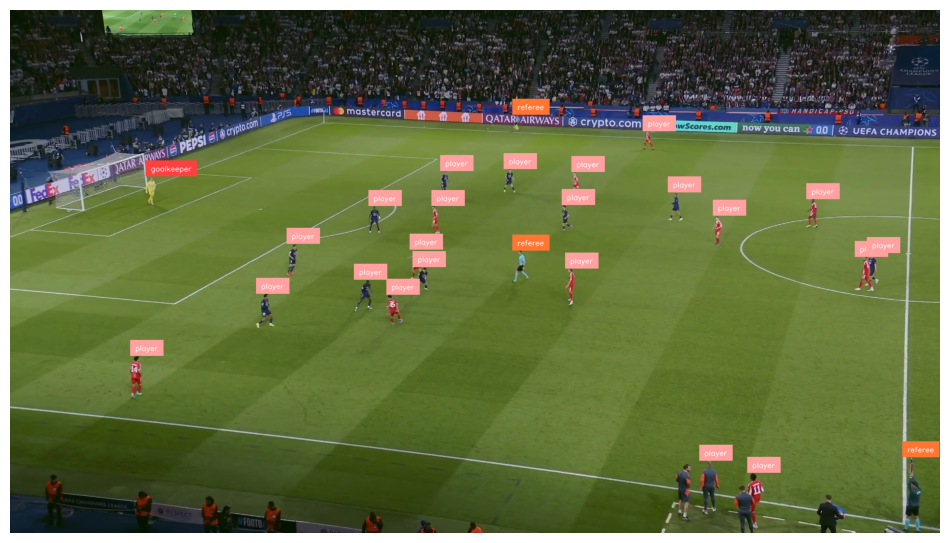

Processing Frame 2...
Detections found: 25


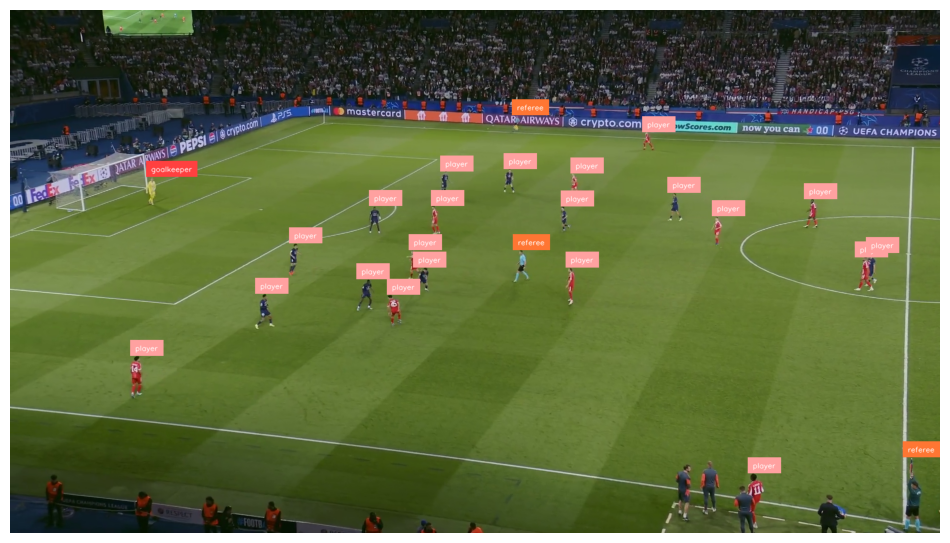

Processing Frame 3...
Detections found: 27


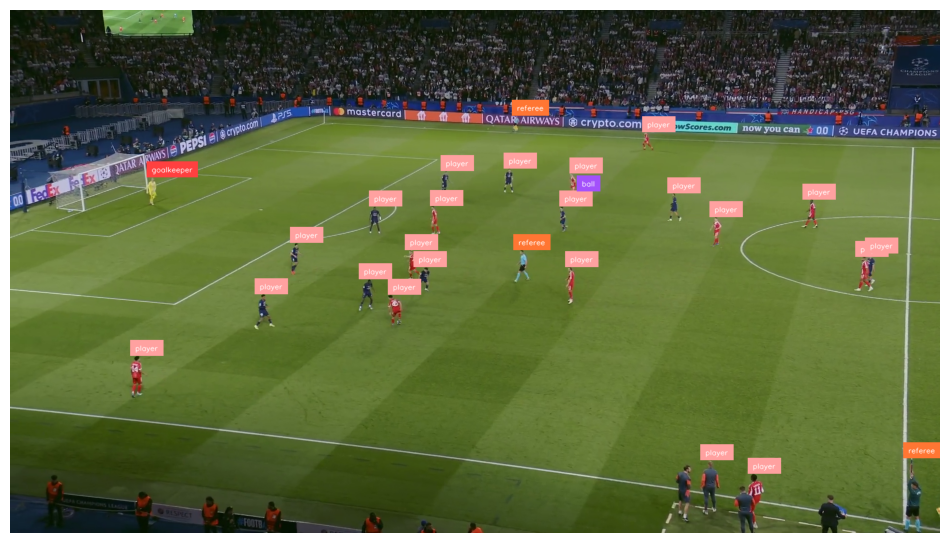

--- Testing Complete ---


In [ ]:
import cv2
import supervision as sv
from inference_sdk import InferenceHTTPClient

# 1. Fetch your API Key safely from Colab Secrets
from google.colab import userdata
try:
    API_KEY = userdata.get('ROBOFLOW_API_KEY')
except Exception:
    raise ValueError("Please add your ROBOFLOW_API_KEY to the Colab Secrets tab.")

# 2. Define your unique Roboflow Model ID
# (Found in your Roboflow deployment tab, looks like "project-name/1")
MODEL_ID = "football-players-detection-3zvbc-ammul/1"

# 3. Initialize the Inference Client
client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key=API_KEY
)

# 4. Load your 5-second video clip
video_path = "/content/bay-psg-shot.mp4"
cap = cv2.VideoCapture(video_path)

frame_count = 0
max_frames_to_test = 3  # Let's test just 3 frames first to verify

print(f"--- Starting inference on the first {max_frames_to_test} frames ---")

while cap.isOpened() and frame_count < max_frames_to_test:
    ret, frame = cap.read()
    if not ret:
        print("End of video or video file not found.")
        break

    frame_count += 1
    print(f"Processing Frame {frame_count}...")

    # 5. Run Inference via Roboflow Serverless API
    results = client.infer(frame, model_id=MODEL_ID)

    # 6. Parse results into Supervision format for clean plotting
    detections = sv.Detections.from_inference(results)

    # 7. Annotate the bounding boxes and labels
    # Note: Modern supervision uses BoxAnnotator and LabelAnnotator independently
    box_annotator = sv.PolygonAnnotator()
    label_annotator = sv.LabelAnnotator()

    annotated_frame = box_annotator.annotate(scene=frame.copy(), detections=detections)
    annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections)

    # 8. Render the frame beautifully in the notebook
    print(f"Detections found: {len(detections)}")
    sv.plot_image(annotated_frame, size=(12, 12))

cap.release()
print("--- Testing Complete ---")

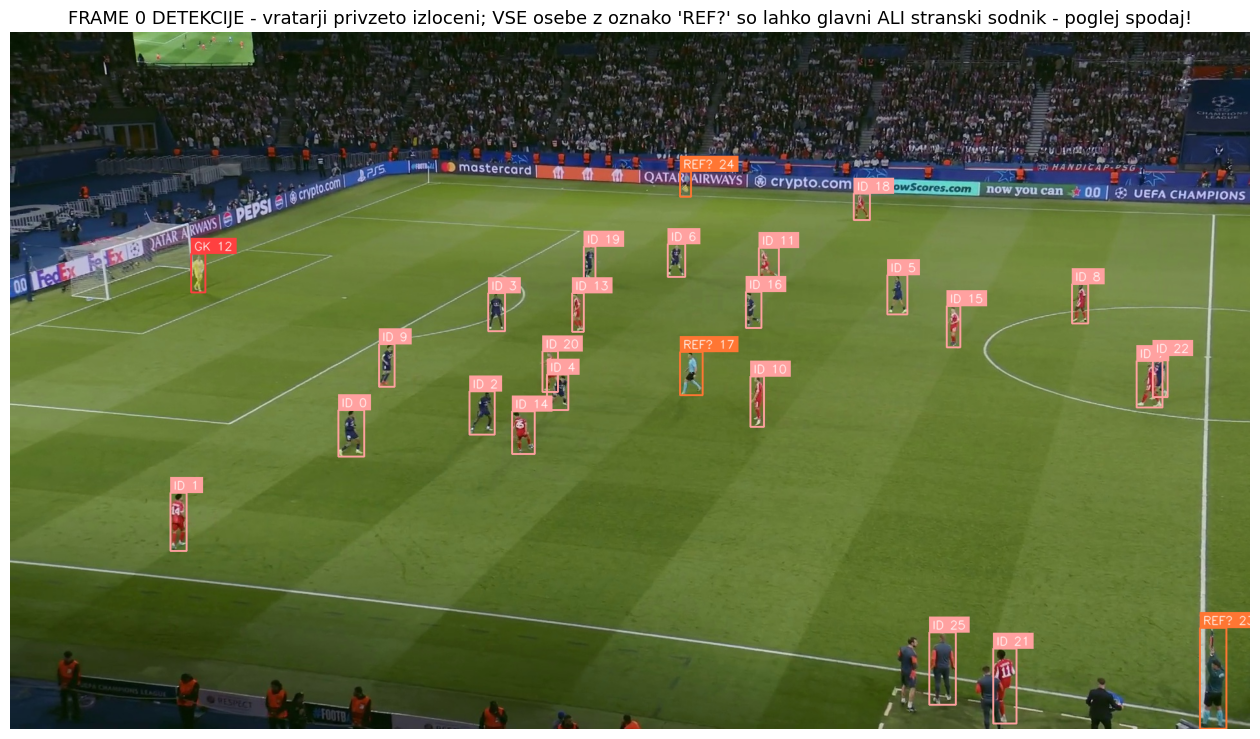

Na Frame 0 zaznan(i) vratar(ji) na indeksih [12] - privzeto izlocen(i) iz zacetnega niza (Celica 3 jih zazna in identificira samodejno).
Model je kot 'sodnik' zaznal indekse [17, 23, 24] - to so lahko glavni sodnik (SLEDI SE) ali stranska sodnika (NE sledita se). Razlikuj jih v spodnjem polju 'Stranska sodnika'.

Popravi seznama spodaj (privzeta izkljucitev vratarjev je ze vpisana) in klikni 'Potrdi izbiro':


Text(value='12', description='Izkljuci ID-je:', layout=Layout(width='450px'), placeholder='npr. 0, 3, 5', styl…

Text(value='', description='Stranska sodnika:', layout=Layout(width='450px'), placeholder='npr. 4, 7  (natanko…

Button(button_style='success', description='Potrdi izbiro', style=ButtonStyle())

Output()

In [ ]:
# ==============================================================================
#INTERAKTIVNA IZBIRA — Frame 0, izkljucitve IN oznacitev stranskih sodnikov
# ==============================================================================
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
import ipywidgets as widgets
from IPython.display import display

REF_ID_OFFSET = 5000
GK_ID_OFFSET  = 20000

def is_player_id(pid: int) -> bool:
    return pid < REF_ID_OFFSET

def is_referee_id(pid: int) -> bool:
    return REF_ID_OFFSET <= pid < GK_ID_OFFSET

def is_goalkeeper_id(pid: int) -> bool:
    return pid >= GK_ID_OFFSET

def load_first_frame(frame_dir: str):
    frames = sorted(
        f for f in os.listdir(frame_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )
    if not frames:
        raise FileNotFoundError(
            f"Ni okvirjev v {frame_dir}. Preveri, da je Celica 1 uspesno ekstrahirala okvirje."
        )
    frame_0 = cv2.imread(os.path.join(frame_dir, frames[0]))
    if frame_0 is None:
        raise ValueError(f"Ni bilo mogoce nalozili slike {frames[0]}")
    return frame_0, frames


def detect_frame0_objects(frame, model_id: str) -> sv.Detections:
    results = client.infer(frame, model_id=model_id)
    return sv.Detections.from_inference(results).with_nms(threshold=0.4)


def find_class_indices(detections: sv.Detections, class_mapping: dict, class_names: tuple) -> set:
    """Poisce indekse detekcij za katerikoli razred (GK, referee, ...)."""
    target_class_id = next(
        (v for k, v in class_mapping.items() if str(k).lower() in class_names),
        None,
    )
    if target_class_id is None or detections.class_id is None:
        return set()
    return {idx for idx, cid in enumerate(detections.class_id) if cid == target_class_id}


def render_annotated_frame(frame, detections: sv.Detections, gk_indices: set, ref_indices: set):
    """Oznaci Frame 0 z ID stevilkami; vratarje z GK, sodnike z REF?."""
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator(text_scale=0.6, text_padding=5)

    annotated = box_annotator.annotate(scene=frame.copy(), detections=detections)
    labels = []
    for idx in range(len(detections)):
        if idx in gk_indices:
            labels.append(f"GK {idx}")
        elif idx in ref_indices:
            labels.append(f"REF? {idx}")
        else:
            labels.append(f"ID {idx}")
    return label_annotator.annotate(scene=annotated, detections=detections, labels=labels)


# ── 1. Detekcija na Frame 0 ────────────────────────────────────────────────────
frame_0, all_frames = load_first_frame(TEMP_FRAME_DIR)
detections = detect_frame0_objects(frame_0, MODEL_ID)

goalkeeper_indices = find_class_indices(detections, CLASS_MAPPING, ("goalkeeper", "gk", "vratar"))
referee_indices    = find_class_indices(detections, CLASS_MAPPING, ("referee", "sodnik"))

# ── 2. Prikaz oznacenega okvirja ───────────────────────────────────────────────
annotated_frame_0 = render_annotated_frame(frame_0, detections, goalkeeper_indices, referee_indices)

plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(annotated_frame_0, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(
    "FRAME 0 DETEKCIJE - vratarji privzeto izloceni; VSE osebe z oznako 'REF?' "
    "so lahko glavni ALI stranski sodnik - poglej spodaj!",
    fontsize=13,
)
plt.show()

if goalkeeper_indices:
    print(f"Na Frame 0 zaznan(i) vratar(ji) na indeksih {sorted(goalkeeper_indices)} - "
          f"privzeto izlocen(i) iz zacetnega niza (Celica 3 jih zazna in identificira samodejno).")

if referee_indices:
    print(f"Model je kot 'sodnik' zaznal indekse {sorted(referee_indices)} - "
          f"to so lahko glavni sodnik (SLEDI SE) ali stranska sodnika (NE sledita se). "
          f"Razlikuj jih v spodnjem polju 'Stranska sodnika'.")

# ── 3. Interaktivni UI za izbiro izkljucitev + stranske sodnike ───────────────
default_exclude = ", ".join(str(i) for i in sorted(goalkeeper_indices))

exclude_w = widgets.Text(
    value=default_exclude,
    placeholder="npr. 0, 3, 5",
    description="Izkljuci ID-je:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="450px"),
)

linesmen_w = widgets.Text(
    value="",
    placeholder="npr. 4, 7  (natanko dva ID-ja stranskih sodnikov)",
    description="Stranska sodnika:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="450px"),
)

button_w = widgets.Button(description="Potrdi izbiro", button_style="success")
output_w = widgets.Output()

selected_boxes = {}
linesmen_ids = set()


def on_confirm_clicked(_):
    global selected_boxes, linesmen_ids
    with output_w:
        output_w.clear_output()

        excluded_ids = {int(item) for item in exclude_w.value.split(",") if item.strip().isdigit()}
        linesmen_ids = {int(item) for item in linesmen_w.value.split(",") if item.strip().isdigit()}

        invalid_linesmen = linesmen_ids - referee_indices
        if invalid_linesmen:
            print(f"Opozorilo: indeksi {sorted(invalid_linesmen)} niso bili zaznani kot "
                  f"razred 'referee' na Frame 0 - preveri, ali si vpisal pravilne ID-je.")

        all_excluded = excluded_ids | linesmen_ids

        # Glavni sodnik = zaznan kot "referee", a NI med izkljucenimi stranskima sodnikoma
        main_referee_indices = referee_indices - linesmen_ids

        # KLJUCNI POPRAVEK: glavnemu sodniku preslikamo Frame-0 indeks v ID iz
        # razpona REF_ID_OFFSET, definiranega v Celici 1. Brez te preslikave
        # bi obj_id ostal enak surovemu indeksu (npr. 6), kar je << REF_ID_OFFSET
        # (5000) - Celica 3 bi ga zato obravnavala kot navadnega igralca in ga
        # razvrstila v eno od dveh ekip.
        selected_boxes = {}
        for idx, xyxy in enumerate(detections.xyxy):
            if idx in all_excluded:
                continue
            if idx in main_referee_indices:
                new_id = REF_ID_OFFSET + idx
                selected_boxes[new_id] = xyxy
            else:
                selected_boxes[idx] = xyxy

        excluded_gk = excluded_ids & goalkeeper_indices

        print(f"Izbira shranjena! Sledim {len(selected_boxes)} objektom z ID-ji: {sorted(selected_boxes.keys())}")
        if linesmen_ids:
            print(f"Stranska sodnika (ID-ji {sorted(linesmen_ids)}) NE bosta sledena.")
        if main_referee_indices:
            remapped = {i: REF_ID_OFFSET + i for i in main_referee_indices}
            print(f"Glavni sodnik preslikan v razpon sodnikov: {remapped} "
                  f"(Celica 3 ga bo prepoznala prek is_referee_id in izkljucila iz razvrscanja v ekipe).")
        if excluded_gk:
            print(f"{len(excluded_gk)} vratar(jev) bo v sledenje dodan(ih) samodejno "
                  f"prek re-identifikacije v Celici 3.")
        print("Sedaj lahko pozenes Celico 3.")


button_w.on_click(on_confirm_clicked)

print("\nPopravi seznama spodaj (privzeta izkljucitev vratarjev je ze vpisana) "
      "in klikni 'Potrdi izbiro':")
display(exclude_w, linesmen_w, button_w, output_w)

In [ ]:
import gc
import os
import pickle
import shutil
import time
import cv2
import numpy as np
import psutil
import supervision as sv
import torch

# ==============================================================================
# KONFIGURACIJA IN POTI
# ==============================================================================

VANILLA_VIDEO_PATH = "/content/vanilla_sam2_tracking.mp4"
VANILLA_PROPAGATED_DB_PATH = "/content/vanilla_sam2_db.pkl"
VANILLA_BALL_CACHE_PATH = "/content/vanilla_sam2_ball.pkl"

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)


BALL_ID = 9999                   # ID za žogo
MIN_MASK_PIXELS_PLAYER = 20      # Najmanjše število pikslov za igralce
MIN_MASK_PIXELS_BALL = 3         # Nižji prag za žogo
CHUNK_SIZE = 100                 # Velikost bloka (za nadzor nad porabo RAM-a)

predictor = build_sam2_video_predictor(

"configs/sam2/sam2_hiera_l.yaml", "sam2.1_hiera_large.pt", device=DEVICE

)

def print_memory_usage(step_name: str):
    """Prikaže trenutno porabo sistemskega RAM-a in GPU VRAM-a."""
    process = psutil.Process(os.getpid())
    ram_gb = process.memory_info().rss / (1024 ** 3)

    if torch.cuda.is_available():
        vram_gb = torch.cuda.memory_allocated() / (1024 ** 3)
        vram_res_gb = torch.cuda.memory_reserved() / (1024 ** 3)
        print(f" 🧠 [{step_name}] RAM: {ram_gb:.2f} GB | GPU VRAM: {vram_gb:.2f} GB (Rezervirano: {vram_res_gb:.2f} GB)")
    else:
        print(f" 🧠 [{step_name}] RAM: {ram_gb:.2f} GB")


# ==============================================================================
# SAMODEJNO ISKANJE PRVE DETEKCIJE ŽOGE
# ==============================================================================

def auto_detect_first_ball(all_frames: list[str], temp_frame_dir: str, model_id: str, class_mapping: dict):
    """Pregleda okvirje od začetka in vrne (frame_idx, box) prve detekcije žoge."""
    print("🔎 Samodejno iščem prvi okvir z detekcijo žoge...")

    # Poisčemo ID razreda za žogo v CLASS_MAPPING
    ball_class_id = next(
        (v for k, v in class_mapping.items() if any(b in str(k).lower() for b in ("ball", "zoga", "žoga"))),
        None
    )

    for frame_idx, fname in enumerate(all_frames):
        frame_path = os.path.join(temp_frame_dir, fname)
        frame = cv2.imread(frame_path)
        if frame is None:
            continue

        results = client.infer(frame, model_id=model_id)
        dets = sv.Detections.from_inference(results).with_nms(threshold=0.3)

        if dets.class_id is not None:
            # Filtriramo detekcije po razredu žoge (ali po imenu, če class_id ni v mapiranju)
            for i, cid in enumerate(dets.class_id):
                if (ball_class_id is not None and cid == ball_class_id) or (ball_class_id is None and "ball" in str(cid).lower()):
                    box = dets.xyxy[i].tolist()
                    print(f"⚽ Žoga samodejno zaznana na okvirju {frame_idx}! Koordinate: {box}")
                    return frame_idx, box

    print("⚠️ Žoga ni bila samodejno zaznana v nobenem okvirju z detektorjem!")
    return None, None


# ==============================================================================
# PRIPRAVA INITIAL_PROMPTS (IGRALCI + SAMODEJNA ŽOGA)
# ==============================================================================

initial_prompts = {}

# 1. Dodajanje igralcev/sodnikov iz Frame 0 (iz prejšnje interaktivne celice)
if 'selected_boxes' in globals() and selected_boxes:
    for obj_id, box in selected_boxes.items():
        initial_prompts[obj_id] = {
            "start_frame": 0,
            "box": box
        }
    print(f"✅ Uvoženih {len(selected_boxes)} igralcev/sodnikov z Frame 0.")
else:
    print("⚠️ 'selected_boxes' ni bil najden. Izvedi najprej interaktivno celico!")

# 2. Samodejno poiščemo prvi pojav žoge
ball_start_frame, ball_box = auto_detect_first_ball(all_frames, TEMP_FRAME_DIR, MODEL_ID, CLASS_MAPPING)

if ball_start_frame is not None and ball_box is not None:
    initial_prompts[BALL_ID] = {
        "start_frame": ball_start_frame,
        "box": ball_box
    }
    print(f"⚽ Žoga (BALL_ID {BALL_ID}) bo dodana v sledenje od okvirja {ball_start_frame} naprej.")


# ==============================================================================
# VANILLA SAM2 SLEDENJE PO BLOKIH
# ==============================================================================

def run_vanilla_sam2_tracking_chunked(
    all_frames: list[str],
    initial_prompts: dict[int, dict],
    predictor,
    temp_frame_dir: str,
    video_info: sv.VideoInfo,
    chunk_size: int = CHUNK_SIZE,
    ball_id: int = BALL_ID
) -> tuple[dict, dict]:

    propagated_db: dict[int, dict] = {}
    ball_positions_db: dict[int, tuple[float, float]] = {}

    total_frames = len(all_frames)
    os.makedirs("./outputs", exist_ok=True)

    mask_annotator = sv.MaskAnnotator(opacity=0.4, color_lookup=sv.ColorLookup.TRACK)
    box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.TRACK, thickness=1)
    label_annotator = sv.LabelAnnotator(text_scale=0.4, text_padding=3, color_lookup=sv.ColorLookup.TRACK)

    print(f"\n🎬 Začenjam Vanilla SAM2 sledenje po blokih (velikost bloka: {chunk_size} okvirjev)...")
    print_memory_usage("Začetek")

    start_time = time.time()
    active_prompts = dict(initial_prompts)

    with sv.VideoSink(VANILLA_VIDEO_PATH, video_info) as sink:

        for chunk_start in range(0, total_frames, chunk_size):
            chunk_end = min(chunk_start + chunk_size, total_frames)
            chunk_frame_names = all_frames[chunk_start:chunk_end]

            print(f"\n--- 📦 Obdelava bloka: okvirji {chunk_start} do {chunk_end - 1} ({len(chunk_frame_names)} okvirjev) ---")

            # 1. Ustvarjanje začasne mape za ta blok
            chunk_dir = os.path.join(temp_frame_dir, f"_temp_chunk_{chunk_start}")
            os.makedirs(chunk_dir, exist_ok=True)

            for idx, fname in enumerate(chunk_frame_names):
                src = os.path.join(temp_frame_dir, fname)
                dst = os.path.join(chunk_dir, f"{idx:05d}.jpg")
                if not os.path.exists(dst):
                    try:
                        os.symlink(os.path.abspath(src), dst)
                    except Exception:
                        shutil.copy(src, dst)

            # 2. Inicializacija stanja za blok
            inf_state = predictor.init_state(
                video_path=chunk_dir,
                offload_video_to_cpu=True,
                offload_state_to_cpu=True
            )
            predictor.reset_state(inf_state)

            # 3. Dodajanje promptov znotraj bloka
            for obj_id, p_info in active_prompts.items():
                start_f = p_info["start_frame"]
                box = p_info["box"]

                # Objekt se doda le, če je njegov start_frame že nastopil
                if start_f < chunk_end:
                    local_f = max(0, start_f - chunk_start)
                    predictor.add_new_points_or_box(
                        inference_state=inf_state,
                        frame_idx=local_f,
                        obj_id=obj_id,
                        box=np.array(box, dtype=np.float32),
                    )

            # 4. Propagacija mask znotraj bloka
            with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
                for local_idx, obj_ids, mask_logits in predictor.propagate_in_video(inf_state):
                    global_idx = chunk_start + local_idx
                    propagated_db[global_idx] = {}

                    frame_path = os.path.join(temp_frame_dir, all_frames[global_idx])
                    frame = cv2.imread(frame_path)

                    if len(obj_ids) == 0:
                        sink.write_frame(frame)
                        continue

                    if isinstance(mask_logits, torch.Tensor):
                        stacked_logits = mask_logits.squeeze(1)
                    else:
                        stacked_logits = torch.cat(list(mask_logits), dim=0).squeeze(1)

                    max_logits, winning_indices = torch.max(stacked_logits, dim=0)
                    positive_mask = max_logits > 0.0

                    xyxy_list, mask_list, tracker_ids, labels = [], [], [], []

                    for o_idx, o_id in enumerate(obj_ids):
                        mask = (winning_indices == o_idx) & positive_mask
                        mask_cpu = mask.cpu().numpy()

                        min_pixels = MIN_MASK_PIXELS_BALL if o_id == ball_id else MIN_MASK_PIXELS_PLAYER

                        if mask_cpu.sum() >= min_pixels:
                            y_idx, x_idx = np.where(mask_cpu)
                            x1, y1 = float(x_idx.min()), float(y_idx.min())
                            x2, y2 = float(x_idx.max()), float(y_idx.max())
                            box = [x1, y1, x2, y2]
                            cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0

                            propagated_db[global_idx][o_id] = {
                                "xyxy": box,
                                "center": (cx, cy)
                            }

                            if o_id == ball_id:
                                ball_positions_db[global_idx] = (cx, cy)

                            # Sproti posodabljamo zadnjo znano lokacijo za prenos v naslednji blok
                            active_prompts[o_id] = {
                                "start_frame": global_idx,
                                "box": box
                            }

                            xyxy_list.append(box)
                            mask_list.append(mask_cpu)
                            tracker_ids.append(o_id)

                            if o_id == ball_id:
                                labels.append("BALL")
                            elif o_id >= GK_ID_OFFSET:
                                labels.append(f"GK {o_id}")
                            elif o_id >= REF_ID_OFFSET:
                                labels.append(f"REF {o_id}")
                            else:
                                labels.append(f"ID {o_id}")

                    if xyxy_list:
                        frame_dets = sv.Detections(
                            xyxy=np.array(xyxy_list, dtype=np.float32),
                            mask=np.array(mask_list, dtype=bool),
                            tracker_id=np.array(tracker_ids, dtype=np.int32),
                        )
                        annotated = mask_annotator.annotate(scene=frame, detections=frame_dets)
                        annotated = box_annotator.annotate(scene=annotated, detections=frame_dets)
                        annotated = label_annotator.annotate(scene=annotated, detections=frame_dets, labels=labels)
                        sink.write_frame(annotated)
                    else:
                        sink.write_frame(frame)

            # Čiščenje pomnilnika po bloku
            predictor.reset_state(inf_state)
            del inf_state
            shutil.rmtree(chunk_dir, ignore_errors=True)

            gc.collect()
            torch.cuda.empty_cache()

            print_memory_usage(f"Konec bloka {chunk_start}-{chunk_end}")

    # Poročilo o izvedbi
    end_time = time.time()
    elapsed_time = end_time - start_time
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
    avg_fps = total_frames / elapsed_time if elapsed_time > 0 else 0

    print("\n" + "="*60)
    print("📊 POROČILO O ZMOGLJIVOSTI (VANILLA SAM2)")
    print("="*60)
    print(f"🖥️ Strojna oprema: {gpu_name}")
    print(f"⏱️ Skupni čas izvajanja: {elapsed_time:.2f} s | Hitrost: {avg_fps:.2f} FPS")
    print("="*60)

    # Shranjevanje rezultatov
    print(f"\n💾 Shranjujem `.pkl` datoteke...")
    with open(VANILLA_PROPAGATED_DB_PATH, "wb") as f:
        pickle.dump(propagated_db, f)

    with open(VANILLA_BALL_CACHE_PATH, "wb") as f:
        pickle.dump(ball_positions_db, f)

    print(f"🎉 Sledenje končano!")
    print(f"   - Video shranjen v: {VANILLA_VIDEO_PATH}")
    print(f"   - Igralci DB: {VANILLA_PROPAGATED_DB_PATH}")
    print(f"   - Žoga DB (zaznano {len(ball_positions_db)} okvirjev): {VANILLA_BALL_CACHE_PATH}")

    return propagated_db, ball_positions_db


# ==============================================================================
# ZAGON
# ==============================================================================

vanilla_db, vanilla_ball_db = run_vanilla_sam2_tracking_chunked(
    all_frames=all_frames,
    initial_prompts=initial_prompts,
    predictor=predictor,
    temp_frame_dir=TEMP_FRAME_DIR,
    video_info=video_info,
    chunk_size=CHUNK_SIZE,
    ball_id=BALL_ID
)

✅ Uvoženih 21 igralcev/sodnikov z Frame 0.
🔎 Samodejno iščem prvi okvir z detekcijo žoge...
⚽ Žoga samodejno zaznana na okvirju 2! Koordinate: [1170.0, 375.0, 1178.0, 383.0]
⚽ Žoga (BALL_ID 9999) bo dodana v sledenje od okvirja 2 naprej.

🎬 Začenjam Vanilla SAM2 sledenje po blokih (velikost bloka: 100 okvirjev)...
 🧠 [Začetek] RAM: 2.54 GB | GPU VRAM: 0.98 GB (Rezervirano: 2.04 GB)

--- 📦 Obdelava bloka: okvirji 0 do 99 (100 okvirjev) ---


frame loading (JPEG): 100%|██████████| 100/100 [00:05<00:00, 17.35it/s]
/content/segment-anything-2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/content/segment-anything-2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 100/100 [13:10<00:00,  7.91s/it]


 🧠 [Konec bloka 0-100] RAM: 4.29 GB | GPU VRAM: 1.19 GB (Rezervirano: 1.77 GB)

--- 📦 Obdelava bloka: okvirji 100 do 199 (100 okvirjev) ---


propagate in video: 100%|██████████| 100/100 [13:17<00:00,  7.98s/it]


 🧠 [Konec bloka 100-200] RAM: 4.32 GB | GPU VRAM: 1.19 GB (Rezervirano: 1.73 GB)

--- 📦 Obdelava bloka: okvirji 200 do 299 (100 okvirjev) ---


propagate in video: 100%|██████████| 100/100 [13:16<00:00,  7.96s/it]


 🧠 [Konec bloka 200-300] RAM: 4.36 GB | GPU VRAM: 1.19 GB (Rezervirano: 1.72 GB)

--- 📦 Obdelava bloka: okvirji 300 do 309 (10 okvirjev) ---


propagate in video: 100%|██████████| 10/10 [00:57<00:00,  5.79s/it]


 🧠 [Konec bloka 300-310] RAM: 4.32 GB | GPU VRAM: 1.19 GB (Rezervirano: 1.72 GB)

📊 POROČILO O ZMOGLJIVOSTI (VANILLA SAM2)
🖥️ Strojna oprema: Tesla T4
⏱️ Skupni čas izvajanja: 2489.41 s | Hitrost: 0.12 FPS

💾 Shranjujem `.pkl` datoteke...
🎉 Sledenje končano!
   - Video shranjen v: /content/vanilla_sam2_tracking.mp4
   - Igralci DB: /content/vanilla_sam2_db.pkl
   - Žoga DB (zaznano 110 okvirjev): /content/vanilla_sam2_ball.pkl


In [ ]:
# ==============================================================================
# DEEPSORT SLEDENJE — SAMO IGRALCI (Z RF-DETR DETEKCIJAMI NA VSAKEM OKVIRJU)
# ==============================================================================

import os
import cv2
import pickle
import torch
import time
import psutil
import numpy as np
import supervision as sv
from inference_sdk import InferenceHTTPClient
from google.colab import userdata
from deep_sort_realtime.deepsort_tracker import DeepSort

# ------------------------------------------------------------------------------
# 1. NASTAVITVE POTI IN MODELOV
# ------------------------------------------------------------------------------
VIDEO_PATH      = "/content/bay-psg-shot.mp4"
TEMP_FRAME_DIR  = "./temp_sam2_frames"
MODEL_ID        = "football-players-detection-3zvbc-ammul/1"
OUTPUT_PKL      = "/content/deepsort_results.pkl"

CLASS_MAPPING = {"ball": 0, "goalkeeper": 1, "player": 2, "referee": 3}
PLAYER_CLASS_ID = CLASS_MAPPING["player"]   # sledimo SAMO temu razredu — enako kot SAM2 pipeline

os.makedirs(TEMP_FRAME_DIR, exist_ok=True)
existing_frames = sorted([f for f in os.listdir(TEMP_FRAME_DIR) if f.endswith('.jpg')])

if len(existing_frames) == 0:
    print(f"🎬 Mapa '{TEMP_FRAME_DIR}' je prazna. Ekstrahiram okvirje iz videa...")
    cap = cv2.VideoCapture(VIDEO_PATH)
    if not cap.isOpened():
        raise FileNotFoundError(f"❌ Ne najdem videoposnetka na poti: '{VIDEO_PATH}'")
    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        cv2.imwrite(os.path.join(TEMP_FRAME_DIR, f"{frame_count:05d}.jpg"), frame)
        frame_count += 1
    cap.release()
    print(f"✅ Ekstrahiranih {frame_count} okvirjev v '{TEMP_FRAME_DIR}'.")

all_jpg_files = sorted([f for f in os.listdir(TEMP_FRAME_DIR) if f.endswith('.jpg')])
total_frames = len(all_jpg_files)

# Pridobitev informacij o videu za FPS in trajanje
cap_info = cv2.VideoCapture(VIDEO_PATH)
video_fps = cap_info.get(cv2.CAP_PROP_FPS)
if not video_fps or video_fps <= 0:
    video_fps = 30.0
cap_info.release()
video_duration_sec = total_frames / video_fps

API_KEY = userdata.get('ROBOFLOW_API_KEY')
client = InferenceHTTPClient(api_url="https://serverless.roboflow.com", api_key=API_KEY)

# ------------------------------------------------------------------------------
# 2. INICIACIJA DEEPSORT SLEDEVALNIKA
# ------------------------------------------------------------------------------
print("1️⃣ Inicializiram DeepSORT sledevalnik (samo igralci)...")

tracker = DeepSort(
    max_age=30,
    n_init=3,
    nms_max_overlap=1.0,
    max_cosine_distance=0.2,
    nn_budget=None,
    embedder="mobilenet",
    half=True,
    bgr=True
)

# ------------------------------------------------------------------------------
# 3. ZANKA SLEDENJA PO OKVIRJIH Z MERITVAMI
# ------------------------------------------------------------------------------
deepsort_results = {}  # Format: {frame_idx: {track_id: [x1, y1, x2, y2]}}

print(f"2️⃣ Začenjam DeepSORT sledenje na {total_frames} okvirjih...")

# Začetek merjenja časa izvajanja
start_time = time.time()

for frame_idx, frame_file in enumerate(all_jpg_files):
    frame_path = os.path.join(TEMP_FRAME_DIR, frame_file)
    frame = cv2.imread(frame_path)
    if frame is None:
        continue

    # A. RF-DETR detekcija na trenutnem okvirju
    results = client.infer(frame, model_id=MODEL_ID)
    detections = sv.Detections.from_inference(results).with_nms(threshold=0.4)

    # B. FILTER: obdrži SAMO detekcije razreda "player"
    detections = detections[detections.class_id == PLAYER_CLASS_ID]

    # C. Pretvorba v DeepSORT format: ([x, y, w, h], confidence, class_name)
    deepsort_detections = []
    for bbox, confidence in zip(detections.xyxy, detections.confidence):
        x1, y1, x2, y2 = bbox
        w, h = x2 - x1, y2 - y1
        conf = float(confidence) if confidence is not None else 0.90
        deepsort_detections.append(([float(x1), float(y1), float(w), float(h)], conf, "player"))

    # D. Posodobitev DeepSORT sledevalnika
    tracks = tracker.update_tracks(deepsort_detections, frame=frame)

    # E. Shranjevanje potrjenih sledi
    deepsort_results[frame_idx] = {}
    for track in tracks:
        if not track.is_confirmed():
            continue
        track_id = int(track.track_id)
        x1, y1, x2, y2 = map(int, track.to_ltrb())
        deepsort_results[frame_idx][track_id] = [x1, y1, x2, y2]

    if (frame_idx + 1) % 10 == 0 or (frame_idx + 1) == total_frames:
        print(f"   Obdelan okvir {frame_idx + 1}/{total_frames} | Aktivne sledi: {len(deepsort_results[frame_idx])}")

# Konec merjenja časa izvajanja
end_time = time.time()
elapsed_time = end_time - start_time

# Izračun metrik hitrosti in strojne opreme
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Ni na voljo (CPU / API klici)"
cpu_info = f"{psutil.cpu_count(logical=True)} jeder"
avg_fps = total_frames / elapsed_time if elapsed_time > 0 else 0
time_per_frame_ms = (elapsed_time / total_frames) * 1000 if total_frames > 0 else 0

print("\n" + "="*60)
print("📊 POROČILO O ZMOGLJIVOSTI IN HITROSTI IZVAJANJA (DEEPSORT)")
print("="*60)
print(f"🖥️ Uporabljena strojna oprema:")
print(f"   - GPU: {gpu_name}")
print(f"   - CPU: {cpu_info}")
print(f"🎥 Dolžina testnega videa:")
print(f"   - Skupaj okvirjev: {total_frames}")
print(f"   - Trajanje videa: {video_duration_sec:.2f} s (pri {video_fps} FPS)")
print(f"⏱️ Čas obdelave:")
print(f"   - Skupni čas izvajanja: {elapsed_time:.2f} s ({elapsed_time/60:.2f} min)")
print(f"⚡ Povprečna hitrost:")
print(f"   - Povprečni FPS: {avg_fps:.2f} okvirjev/s")
print(f"   - Čas na okvir: {time_per_frame_ms:.2f} ms")
print("="*60)

# ------------------------------------------------------------------------------
# 4. SHRANJEVANJE
# ------------------------------------------------------------------------------
with open(OUTPUT_PKL, "wb") as f:
    pickle.dump(deepsort_results, f)

print("\n🎉 DeepSORT sledenje (samo igralci) je uspešno zaključeno!")
print(f"✅ Rezultati shranjeni v '{OUTPUT_PKL}'.")

1️⃣ Inicializiram DeepSORT sledevalnik (samo igralci)...
2️⃣ Začenjam DeepSORT sledenje na 364 okvirjih...
   Obdelan okvir 10/364 | Aktivne sledi: 20
   Obdelan okvir 20/364 | Aktivne sledi: 20
   Obdelan okvir 30/364 | Aktivne sledi: 20
   Obdelan okvir 40/364 | Aktivne sledi: 20
   Obdelan okvir 50/364 | Aktivne sledi: 20
   Obdelan okvir 60/364 | Aktivne sledi: 20
   Obdelan okvir 70/364 | Aktivne sledi: 20
   Obdelan okvir 80/364 | Aktivne sledi: 20
   Obdelan okvir 90/364 | Aktivne sledi: 20
   Obdelan okvir 100/364 | Aktivne sledi: 20
   Obdelan okvir 110/364 | Aktivne sledi: 20
   Obdelan okvir 120/364 | Aktivne sledi: 20
   Obdelan okvir 130/364 | Aktivne sledi: 20
   Obdelan okvir 140/364 | Aktivne sledi: 20
   Obdelan okvir 150/364 | Aktivne sledi: 20
   Obdelan okvir 160/364 | Aktivne sledi: 20
   Obdelan okvir 170/364 | Aktivne sledi: 20
   Obdelan okvir 180/364 | Aktivne sledi: 20
   Obdelan okvir 190/364 | Aktivne sledi: 20
   Obdelan okvir 200/364 | Aktivne sledi: 20
  

In [ ]:
# ==============================================================================
# BYTETRACK SLEDENJE — SAMO IGRALCI (Z RF-DETR DETEKCIJAMI NA VSAKEM OKVIRJU)
# ==============================================================================

import os
import cv2
import pickle
import time
import psutil
import torch
import numpy as np
import supervision as sv
from inference_sdk import InferenceHTTPClient
from google.colab import userdata

# ------------------------------------------------------------------------------
# 1. NASTAVITVE POTI IN MODELOV
# ------------------------------------------------------------------------------
TEMP_FRAME_DIR = "./temp_sam2_frames"
MODEL_ID       = "football-players-detection-3zvbc-ammul/1"
OUTPUT_PKL     = "/content/bytetrack_results.pkl"

CLASS_MAPPING   = {"ball": 0, "goalkeeper": 1, "player": 2, "referee": 3}
PLAYER_CLASS_ID = CLASS_MAPPING["player"]   # sledimo SAMO temu razredu — enako kot SAM2 pipeline

if not os.path.exists(TEMP_FRAME_DIR):
    raise RuntimeError(f"❌ Mapa '{TEMP_FRAME_DIR}' ne obstaja!")

all_jpg_files = sorted([f for f in os.listdir(TEMP_FRAME_DIR) if f.endswith('.jpg')])
total_frames = len(all_jpg_files)

# Predpostavka za trajanje videa (če ni drugega vira, privzamemo 30 FPS)
video_fps = 30.0
video_duration_sec = total_frames / video_fps

API_KEY = userdata.get('ROBOFLOW_API_KEY')
client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key=API_KEY
)

# ------------------------------------------------------------------------------
# 2. INICIALIZACIJA BYTETRACK SLEDEVALNIKA
# ------------------------------------------------------------------------------
print("1️⃣ Inicializiram ByteTrack sledevalnik (samo igralci)...")

byte_tracker = sv.ByteTrack(
    track_activation_threshold=0.25,
    lost_track_buffer=30,
    minimum_matching_threshold=0.8,
    frame_rate=30
)

# ------------------------------------------------------------------------------
# 3. ZANKA SLEDENJA PO OKVIRJIH Z MERITVAMI
# ------------------------------------------------------------------------------
bytetrack_results = {}  # Format: {frame_idx: {track_id: [x1, y1, x2, y2]}}

print(f"2️⃣ Začenjam ByteTrack sledenje na {total_frames} okvirjih...")

# Začetek merjenja časa izvajanja
start_time = time.time()

for frame_idx, frame_file in enumerate(all_jpg_files):
    frame_path = os.path.join(TEMP_FRAME_DIR, frame_file)
    frame = cv2.imread(frame_path)
    if frame is None:
        continue

    # A. RF-DETR detekcija na trenutnem okvirju
    results = client.infer(frame, model_id=MODEL_ID)
    detections = sv.Detections.from_inference(results).with_nms(threshold=0.4)

    # B. FILTER: obdrži SAMO detekcije razreda "player"
    detections = detections[detections.class_id == PLAYER_CLASS_ID]

    # C. Posodobitev ByteTrack sledevalnika z (že prefiltriranimi) detekcijami
    detections = byte_tracker.update_with_detections(detections=detections)

    # D. Shranjevanje rezultatov
    bytetrack_results[frame_idx] = {}
    if detections.tracker_id is not None:
        for bbox, tracker_id in zip(detections.xyxy, detections.tracker_id):
            x1, y1, x2, y2 = map(int, bbox)
            bytetrack_results[frame_idx][int(tracker_id)] = [x1, y1, x2, y2]

    if (frame_idx + 1) % 10 == 0 or (frame_idx + 1) == total_frames:
        print(f"   Obdelan okvir {frame_idx + 1}/{total_frames} | Aktivne sledi: {len(bytetrack_results[frame_idx])}")

# Konec merjenja časa izvajanja
end_time = time.time()
elapsed_time = end_time - start_time

# Izračun metrik hitrosti in strojne opreme
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Ni na voljo (CPU / API klici)"
cpu_info = f"{psutil.cpu_count(logical=True)} jeder"
avg_fps = total_frames / elapsed_time if elapsed_time > 0 else 0
time_per_frame_ms = (elapsed_time / total_frames) * 1000 if total_frames > 0 else 0

print("\n" + "="*60)
print("📊 POROČILO O ZMOGLJIVOSTI IN HITROSTI IZVAJANJA (BYTETRACK)")
print("="*60)
print(f"🖥️ Uporabljena strojna oprema:")
print(f"   - GPU: {gpu_name}")
print(f"   - CPU: {cpu_info}")
print(f"🎥 Dolžina testnega videa:")
print(f"   - Skupaj okvirjev: {total_frames}")
print(f"   - Trajanje videa: {video_duration_sec:.2f} s (pri {video_fps} FPS)")
print(f"⏱️ Čas obdelave:")
print(f"   - Skupni čas izvajanja: {elapsed_time:.2f} s ({elapsed_time/60:.2f} min)")
print(f"⚡ Povprečna hitrost:")
print(f"   - Povprečni FPS: {avg_fps:.2f} okvirjev/s")
print(f"   - Čas na okvir: {time_per_frame_ms:.2f} ms")
print("="*60)

# ------------------------------------------------------------------------------
# 4. SHRANJEVANJE
# ------------------------------------------------------------------------------
with open(OUTPUT_PKL, "wb") as f:
    pickle.dump(bytetrack_results, f)

print("\n🎉 ByteTrack sledenje (samo igralci) je uspešno zaključeno!")
print(f"✅ Rezultati shranjeni v '{OUTPUT_PKL}'.")

1️⃣ Inicializiram ByteTrack sledevalnik (samo igralci)...
2️⃣ Začenjam ByteTrack sledenje na 364 okvirjih...


/tmp/ipykernel_2988/992769501.py:47: FutureWarning: The `ByteTrack` was deprecated since v0.28.0. It will be removed in v0.31.0.
  byte_tracker = sv.ByteTrack(


   Obdelan okvir 10/364 | Aktivne sledi: 20
   Obdelan okvir 20/364 | Aktivne sledi: 20
   Obdelan okvir 30/364 | Aktivne sledi: 20
   Obdelan okvir 40/364 | Aktivne sledi: 20
   Obdelan okvir 50/364 | Aktivne sledi: 20
   Obdelan okvir 60/364 | Aktivne sledi: 20
   Obdelan okvir 70/364 | Aktivne sledi: 20
   Obdelan okvir 80/364 | Aktivne sledi: 20
   Obdelan okvir 90/364 | Aktivne sledi: 20
   Obdelan okvir 100/364 | Aktivne sledi: 20
   Obdelan okvir 110/364 | Aktivne sledi: 20
   Obdelan okvir 120/364 | Aktivne sledi: 20
   Obdelan okvir 130/364 | Aktivne sledi: 20
   Obdelan okvir 140/364 | Aktivne sledi: 20
   Obdelan okvir 150/364 | Aktivne sledi: 20
   Obdelan okvir 160/364 | Aktivne sledi: 20
   Obdelan okvir 170/364 | Aktivne sledi: 20
   Obdelan okvir 180/364 | Aktivne sledi: 20
   Obdelan okvir 190/364 | Aktivne sledi: 20
   Obdelan okvir 200/364 | Aktivne sledi: 20
   Obdelan okvir 210/364 | Aktivne sledi: 20
   Obdelan okvir 220/364 | Aktivne sledi: 20
   Obdelan okvir 23

In [ ]:
# ==============================================================================
# PRIMERJAVA SLEDEVALNIKOV: DeepSORT vs ByteTrack vs Vanilla SAM2 vs Predlagani SAM2
# Evalvacija na razredu "Player" iz CVAT XML izvoza
# ==============================================================================

!pip install -q motmetrics

import os
import pickle
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import motmetrics as mm

# Popravek za združljivost starejših/novejših verzij NumPy z motmetrics
if not hasattr(np, "asfarray"):
    np.asfarray = lambda a, dtype=np.float64: np.asarray(a, dtype=dtype)

# ── Poti do datotek ──────────────────────────────────────────────────────────
CVAT_XML_PATH           = "/content/annotations.xml"  # CVAT XML datoteka z GT oznakami

DEEPSORT_PKL            = "/content/deepsort_results.pkl"
BYTETRACK_PKL           = "/content/bytetrack_results.pkl"

# Vanilla SAM2
VANILLA_SAM2_PATHS      = ["/content/vanilla_sam2_db.pkl", "./outputs/vanilla_sam2_db.pkl"]

# Predlagani SAM2 (hibrid z urejanjem)
PROPAGATED_DB_PATHS     = ["/content/propagated_db.pkl", "./outputs/propagated_db.pkl"]
LOCKED_ASSIGNMENTS_PATH = "/content/locked_track_assignments.pkl"

IOU_THRESHOLD = 0.5

# ══════════════════════════════════════════════════════════════════════════════
# 1. GT — naloži iz CVAT XML in filtriraj SAMO terenske igralce ("player")
# ══════════════════════════════════════════════════════════════════════════════
print("📂 Nalagam Ground Truth (GT) iz CVAT XML...")

if not os.path.exists(CVAT_XML_PATH):
    raise FileNotFoundError(f"❌ XML datoteka ne obstaja na poti: {CVAT_XML_PATH}")

tree = ET.parse(CVAT_XML_PATH)
root = tree.getroot()

gt_rows = []
for track in root.findall('track'):
    track_id = int(track.attrib['id'])
    label = track.attrib.get('label', '').strip().lower()

    for box in track.findall('box'):
        # Preskočimo okvirje, kjer je objekt izven vidnega polja (outside = 1)
        outside = int(box.attrib.get('outside', '0'))
        if outside != 0:
            continue

        frame = int(box.attrib['frame'])
        xtl = float(box.attrib['xtl'])
        ytl = float(box.attrib['ytl'])
        xbr = float(box.attrib['xbr'])
        ybr = float(box.attrib['ybr'])

        gt_rows.append({
            'frame': frame,
            'track_id': track_id,
            'x': xtl,
            'y': ytl,
            'w': xbr - xtl,
            'h': ybr - ytl,
            'x2': xbr,
            'y2': ybr,
            'class_name': label
        })

gt_df = pd.DataFrame(gt_rows)

print("GT razredi v XML datoteki:", gt_df["class_name"].value_counts().to_dict())

# Filtriramo samo terenske igralce (izključimo sodnike in golmane)
player_labels = ["player", "igralec"]
gt_players = gt_df[gt_df["class_name"].isin(player_labels)].copy()

unique_player_ids = sorted(gt_players['track_id'].unique())
print(f"✅ GT vrstic (samo Player): {len(gt_players)} | GT sledi (Player): {len(unique_player_ids)}")
print(f"📋 Zaznani Player ID-ji v GT: {unique_player_ids}")

# ══════════════════════════════════════════════════════════════════════════════
# 2. Pomožna funkcija za pretvorbo {frame: {track_id: box_or_dict}} v DataFrame
# ══════════════════════════════════════════════════════════════════════════════
def dict_to_df(results_dict, player_only_sam2=False, locked_assignments=None):
    """
    Pretvori slovar rezultatov v DataFrame.
    Podpira tako formata:
      - {frame: {track_id: [x1, y1, x2, y2]}}
      - {frame: {track_id: {"xyxy": [x1, y1, x2, y2]}}}
    """
    if locked_assignments is None:
        locked_assignments = {}

    gk_keywords = ["gk", "golman", "goalkeeper", "keeper"]

    rows = []
    for frame_idx, tracks in results_dict.items():
        for track_id, data in tracks.items():
            track_id = int(track_id)

            # Če filtriramo SAM2 objekte, obdržimo le igralce
            if player_only_sam2:
                role = str(locked_assignments.get(track_id, "")).lower()

                is_gk = any(gk in role for gk in gk_keywords) or role.endswith("_gk")
                is_referee = role in ["referee", "sodnik", "ref"]

                # Izločimo le potrjene golmane in sodnike, vsi terenski igralci (tudi ID 20+) ostanejo
                if is_gk or is_referee:
                    continue

            # Ekstrakcija koordinat
            if isinstance(data, dict) and "xyxy" in data:
                x1, y1, x2, y2 = data["xyxy"]
            elif isinstance(data, (list, tuple, np.ndarray)):
                x1, y1, x2, y2 = data
            else:
                continue

            rows.append({
                "frame": int(frame_idx),
                "track_id": track_id,
                "x": float(x1),
                "y": float(y1),
                "x2": float(x2),
                "y2": float(y2),
                "w": float(x2 - x1),
                "h": float(y2 - y1),
            })
    return pd.DataFrame(rows)

def find_file(path_list):
    """Pomožna funkcija, ki vrne prvo obstoječo pot iz seznama."""
    for p in path_list:
        if os.path.exists(p):
            return p
    return None

# ══════════════════════════════════════════════════════════════════════════════
# 3. Naloži rezultate vseh sledevalnikov
# ══════════════════════════════════════════════════════════════════════════════
methods = {}

# --- A) DeepSORT ---
if os.path.exists(DEEPSORT_PKL):
    print("\n🔹 Nalagam DeepSORT...")
    with open(DEEPSORT_PKL, "rb") as f:
        deepsort_raw = pickle.load(f)
    deepsort_df = dict_to_df(deepsort_raw)
    methods["DeepSORT"] = deepsort_df
    print(f"   DeepSORT: {len(deepsort_df)} vrstic, {deepsort_df['track_id'].nunique() if len(deepsort_df) else 0} sledi")
else:
    print(f"\n⚠️ DeepSORT datoteka ne obstaja na: {DEEPSORT_PKL}")

# --- B) ByteTrack ---
if os.path.exists(BYTETRACK_PKL):
    print("\n🔹 Nalagam ByteTrack...")
    with open(BYTETRACK_PKL, "rb") as f:
        bytetrack_raw = pickle.load(f)
    bytetrack_df = dict_to_df(bytetrack_raw)
    methods["ByteTrack"] = bytetrack_df
    print(f"   ByteTrack: {len(bytetrack_df)} vrstic, {bytetrack_df['track_id'].nunique() if len(bytetrack_df) else 0} sledi")
else:
    print(f"\n⚠️ ByteTrack datoteka ne obstaja na: {BYTETRACK_PKL}")

# --- C) Vanilla SAM2 (osnovni, brez popravkov) ---
vanilla_path = find_file(VANILLA_SAM2_PATHS)
if vanilla_path:
    print(f"\n🔹 Nalagam Vanilla SAM2 ({vanilla_path})...")
    with open(vanilla_path, "rb") as f:
        vanilla_raw = pickle.load(f)
    vanilla_df = dict_to_df(vanilla_raw, player_only_sam2=True)
    methods["SAM2 (Vanilla)"] = vanilla_df
    print(f"   Vanilla SAM2 (samo igralci): {len(vanilla_df)} vrstic, {vanilla_df['track_id'].nunique() if len(vanilla_df) else 0} sledi")
else:
    print(f"\n⚠️ Vanilla SAM2 datoteka ni bila najdena v {VANILLA_SAM2_PATHS}")

# --- D) Predlagani SAM2 (hibridni, z urejanjem in re-detekcijo) ---
propagated_path = find_file(PROPAGATED_DB_PATHS)
if propagated_path:
    print(f"\n🔹 Nalagam Predlagani SAM2 ({propagated_path})...")
    with open(propagated_path, "rb") as f:
        propagated_db = pickle.load(f)

    locked_assignments = {}
    if os.path.exists(LOCKED_ASSIGNMENTS_PATH):
        with open(LOCKED_ASSIGNMENTS_PATH, "rb") as f:
            locked_assignments = pickle.load(f)

    sam2_prop_df = dict_to_df(propagated_db, player_only_sam2=True, locked_assignments=locked_assignments)
    methods["SAM2 (Predlagani)"] = sam2_prop_df
    print(f"   Predlagani SAM2 (samo igralci): {len(sam2_prop_df)} vrstic, {sam2_prop_df['track_id'].nunique() if len(sam2_prop_df) else 0} sledi")
else:
    print(f"\n⚠️ Predlagani SAM2 datoteka ni bila najdena v {PROPAGATED_DB_PATHS}")

# ══════════════════════════════════════════════════════════════════════════════
# 4. Izračun MOT metrik (MOTA, MOTP, IDF1, ID Switches, FP, FN...)
# ══════════════════════════════════════════════════════════════════════════════
def run_mot_eval(gt_sub, pred_sub, name):
    if len(gt_sub) == 0:
        print(f"[{name}] Ni GT vrstic — preskočeno.")
        return None
    if len(pred_sub) == 0:
        print(f"[{name}] Ni napovedanih vrstic — preskočeno.")
        return None

    acc = mm.MOTAccumulator(auto_id=True)
    all_frames = sorted(set(gt_sub["frame"]).union(set(pred_sub["frame"])))

    for frame in all_frames:
        gt_frame   = gt_sub[gt_sub["frame"] == frame]
        pred_frame = pred_sub[pred_sub["frame"] == frame]

        gt_ids   = gt_frame["track_id"].tolist()
        pred_ids = pred_frame["track_id"].tolist()

        gt_boxes   = gt_frame[["x", "y", "w", "h"]].values
        pred_boxes = pred_frame[["x", "y", "w", "h"]].values

        dist_matrix = mm.distances.iou_matrix(gt_boxes, pred_boxes, max_iou=IOU_THRESHOLD)
        acc.update(gt_ids, pred_ids, dist_matrix)

    mh = mm.metrics.create()
    summary = mh.compute(
        acc,
        metrics=["num_frames", "mota", "motp", "idf1", "idp", "idr",
                 "num_switches", "num_false_positives", "num_misses",
                 "num_fragmentations", "mostly_tracked", "mostly_lost"],
        name=name,
    )
    return summary

print("\n" + "="*75)
print("🚀 Poganjam MOT evalvacijo za vse vključene metode (samo razred 'Player')...")
print("="*75)

results = []
for name, df in methods.items():
    r = run_mot_eval(gt_players, df, name)
    if r is not None:
        results.append(r)

if results:
    full_summary = pd.concat(results)
    mh = mm.metrics.create()
    strsummary = mm.io.render_summary(
        full_summary,
        formatters=mh.formatters,
        namemap=mm.io.motchallenge_metric_names,
    )
    print("\n══════════════════ PRIMERJAVA SLEDEVALNIKOV — IGRALCI ══════════════════")
    print(strsummary)

    # Shranjevanje v CSV
    output_csv = "/content/tracker_comparison_players.csv"
    full_summary.to_csv(output_csv)
    print(f"\n✅ Rezultati uspešno shranjeni v '{output_csv}'")
else:
    print("❌ Ni rezultatov za izpis.")

📂 Nalagam Ground Truth (GT) iz CVAT XML...


FileNotFoundError: ❌ XML datoteka ne obstaja na poti: /content/annotations.xml

In [ ]:
# ==============================================================================
# PRIMERJAVA SLEDEVALNIKOV + NET IDENTITY SWITCH ANALIZA (CVAT XML Export)
# ==============================================================================

!pip install -q motmetrics

import os
import pickle
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import motmetrics as mm

# Popravek za združljivost starejših/novejših verzij NumPy z motmetrics
if not hasattr(np, "asfarray"):
    np.asfarray = lambda a, dtype=np.float64: np.asarray(a, dtype=dtype)

# ── Poti do datotek ──────────────────────────────────────────────────────────
CVAT_XML_PATH           = "/content/annotations.xml"  # CVAT XML z GT oznakami

DEEPSORT_PKL            = "/content/deepsort_results.pkl"
BYTETRACK_PKL           = "/content/bytetrack_results.pkl"

# Vanilla SAM2
VANILLA_SAM2_PATHS      = ["/content/vanilla_sam2_db.pkl", "./outputs/vanilla_sam2_db.pkl"]

# Predlagani SAM2 (hibrid z urejanjem)
PROPAGATED_DB_PATHS     = ["/content/propagated_db.pkl", "./outputs/propagated_db.pkl"]
LOCKED_ASSIGNMENTS_PATH = "/content/locked_track_assignments.pkl"

IOU_THRESHOLD = 0.5

# ══════════════════════════════════════════════════════════════════════════════
# 1. Ground Truth — Nalaganje in filtriranje iz CVAT XML
# ══════════════════════════════════════════════════════════════════════════════
print("📂 Nalagam Ground Truth (GT) iz CVAT XML...")

if not os.path.exists(CVAT_XML_PATH):
    raise FileNotFoundError(f"❌ XML datoteka ne obstaja na poti: {CVAT_XML_PATH}")

tree = ET.parse(CVAT_XML_PATH)
root = tree.getroot()

gt_rows = []
for track in root.findall('track'):
    track_id = int(track.attrib['id'])
    label = track.attrib.get('label', '').strip().lower()

    for box in track.findall('box'):
        # Preskočimo okvirje, kjer je objekt izven vidnega polja (outside = 1)
        outside = int(box.attrib.get('outside', '0'))
        if outside != 0:
            continue

        frame = int(box.attrib['frame'])
        xtl = float(box.attrib['xtl'])
        ytl = float(box.attrib['ytl'])
        xbr = float(box.attrib['xbr'])
        ybr = float(box.attrib['ybr'])

        gt_rows.append({
            'frame': frame,
            'track_id': track_id,
            'x': xtl,
            'y': ytl,
            'w': xbr - xtl,
            'h': ybr - ytl,
            'x2': xbr,
            'y2': ybr,
            'class_name': label
        })

gt_df = pd.DataFrame(gt_rows)

print("GT razredi v XML datoteki:", gt_df["class_name"].value_counts().to_dict())

# Filtriramo samo terenske igralce ("player", "igralec")
player_labels = ["player", "igralec"]
gt_players = gt_df[gt_df["class_name"].isin(player_labels)].copy()

unique_player_ids = sorted(gt_players['track_id'].unique())
print(f"✅ GT vrstic (samo Player): {len(gt_players)} | GT sledi (Player): {len(unique_player_ids)}")
print(f"📋 Zaznani Player ID-ji v GT: {unique_player_ids}")

# ══════════════════════════════════════════════════════════════════════════════
# 2. Pomožne funkcije za pretvorbo in iskanje datotek
# ══════════════════════════════════════════════════════════════════════════════
def dict_to_df(results_dict, player_only_sam2=False, locked_assignments=None):
    """Pretvori slovar rezultatov v DataFrame."""
    if locked_assignments is None:
        locked_assignments = {}

    gk_keywords = ["gk", "golman", "goalkeeper", "keeper"]

    rows = []
    for frame_idx, tracks in results_dict.items():
        for track_id, data in tracks.items():
            track_id = int(track_id)

            if player_only_sam2:
                role = str(locked_assignments.get(track_id, "")).lower()
                is_gk = any(gk in role for gk in gk_keywords) or role.endswith("_gk")
                is_referee = role in ["referee", "sodnik", "ref"]

                # Izločimo le potrjene golmane in sodnike
                if is_gk or is_referee:
                    continue

            if isinstance(data, dict) and "xyxy" in data:
                x1, y1, x2, y2 = data["xyxy"]
            elif isinstance(data, (list, tuple, np.ndarray)):
                x1, y1, x2, y2 = data
            else:
                continue

            rows.append({
                "frame": int(frame_idx),
                "track_id": track_id,
                "x": float(x1),
                "y": float(y1),
                "x2": float(x2),
                "y2": float(y2),
                "w": float(x2 - x1),
                "h": float(y2 - y1),
            })
    return pd.DataFrame(rows)

def find_file(path_list):
    """Vrne prvo obstoječo pot iz seznama."""
    for p in path_list:
        if os.path.exists(p):
            return p
    return None

# ══════════════════════════════════════════════════════════════════════════════
# 3. Naloži rezultate vseh sledevalnikov
# ══════════════════════════════════════════════════════════════════════════════
methods = {}

# DeepSORT
if os.path.exists(DEEPSORT_PKL):
    with open(DEEPSORT_PKL, "rb") as f:
        deepsort_raw = pickle.load(f)
    methods["DeepSORT"] = dict_to_df(deepsort_raw)

# ByteTrack
if os.path.exists(BYTETRACK_PKL):
    with open(BYTETRACK_PKL, "rb") as f:
        bytetrack_raw = pickle.load(f)
    methods["ByteTrack"] = dict_to_df(bytetrack_raw)

# Vanilla SAM2
vanilla_path = find_file(VANILLA_SAM2_PATHS)
if vanilla_path:
    with open(vanilla_path, "rb") as f:
        vanilla_raw = pickle.load(f)
    methods["SAM2 (Vanilla)"] = dict_to_df(vanilla_raw, player_only_sam2=True)

# Predlagani SAM2
propagated_path = find_file(PROPAGATED_DB_PATHS)
if propagated_path:
    with open(propagated_path, "rb") as f:
        propagated_db = pickle.load(f)

    locked_assignments = {}
    if os.path.exists(LOCKED_ASSIGNMENTS_PATH):
        with open(LOCKED_ASSIGNMENTS_PATH, "rb") as f:
            locked_assignments = pickle.load(f)

    methods["SAM2 (Predlagani)"] = dict_to_df(propagated_db, player_only_sam2=True, locked_assignments=locked_assignments)

# ══════════════════════════════════════════════════════════════════════════════
# 4. Funkciji za standardno MOT evalvacijo in NET IDSW analizo
# ══════════════════════════════════════════════════════════════════════════════
def run_mot_eval_with_acc(gt_sub, pred_sub, name):
    """Poganja MOTAccumulator in vrne summary ter akumulator."""
    if len(gt_sub) == 0 or len(pred_sub) == 0:
        print(f"[{name}] Ni GT ali napovedanih vrstic — preskočeno.")
        return None, None

    acc = mm.MOTAccumulator(auto_id=True)
    all_frames = sorted(set(gt_sub["frame"]).union(set(pred_sub["frame"])))

    for frame in all_frames:
        gt_frame   = gt_sub[gt_sub["frame"] == frame]
        pred_frame = pred_sub[pred_sub["frame"] == frame]

        gt_ids   = gt_frame["track_id"].tolist()
        pred_ids = pred_frame["track_id"].tolist()

        gt_boxes   = gt_frame[["x", "y", "w", "h"]].values
        pred_boxes = pred_frame[["x", "y", "w", "h"]].values

        dist_matrix = mm.distances.iou_matrix(gt_boxes, pred_boxes, max_iou=IOU_THRESHOLD)
        acc.update(gt_ids, pred_ids, dist_matrix)

    mh = mm.metrics.create()
    summary = mh.compute(
        acc,
        metrics=["num_frames", "mota", "motp", "idf1", "idp", "idr",
                 "num_switches", "num_false_positives", "num_misses",
                 "num_fragmentations", "mostly_tracked", "mostly_lost"],
        name=name,
    )
    return summary, acc


def compute_net_idsw(acc, name):
    """
    Analizira ujemanj GT<->hipoteza ob prvem in zadnjem pojavu posameznega GT igralca.
    Izračuna trajne (Net) zamenjave identitet in loči prehodne (transient) flickerje.
    """
    events = acc.mot_events.reset_index()
    matched = events[events["Type"].isin(["MATCH", "SWITCH"])].copy()
    matched = matched.sort_values("FrameId")

    if len(matched) == 0:
        return {"gt_tracks_matched": 0, "net_idsw": 0, "net_idsw_pct": 0.0,
                "identity_preserved_pct": 0.0, "transient_only_switches": 0}

    first_match = matched.groupby("OId").first()["HId"]
    last_match  = matched.groupby("OId").last()["HId"]

    gt_tracks_matched = matched["OId"].nunique()
    net_switches = int((first_match != last_match).sum())
    identity_preserved = gt_tracks_matched - net_switches

    total_switch_events = int((events["Type"] == "SWITCH").sum())
    transient_only = max(0, total_switch_events - net_switches)

    return {
        "gt_tracks_matched": gt_tracks_matched,
        "net_idsw": net_switches,
        "net_idsw_pct": round(100 * net_switches / gt_tracks_matched, 1) if gt_tracks_matched else 0.0,
        "identity_preserved_pct": round(100 * identity_preserved / gt_tracks_matched, 1) if gt_tracks_matched else 0.0,
        "transient_only_switches": transient_only,
    }

# ══════════════════════════════════════════════════════════════════════════════
# 5. Izvedba analize in izpis rezultatov
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("🚀 Poganjam MOT evalvacijo + Net IDSW analizo (samo razred 'Player')...")
print("="*70)

results = []
net_idsw_rows = []

for name, df in methods.items():
    summary, acc = run_mot_eval_with_acc(gt_players, df, name)
    if summary is None:
        continue
    results.append(summary)

    net_stats = compute_net_idsw(acc, name)
    net_idsw_rows.append({
        "Method": name,
        "GT sledi (ujemane)": net_stats["gt_tracks_matched"],
        "Standardni IDSW": int(summary["num_switches"].iloc[0]),
        "Prehodni (transient) IDSW": net_stats["transient_only_switches"],
        "Net IDSW (začetek≠konec)": net_stats["net_idsw"],
        "Ohranjena identiteta (%)": net_stats["identity_preserved_pct"],
    })

# ── Standardna MOT primerjava ─────────────────────────────────────────────────
if results:
    full_summary = pd.concat(results)
    mh = mm.metrics.create()
    strsummary = mm.io.render_summary(
        full_summary, formatters=mh.formatters, namemap=mm.io.motchallenge_metric_names,
    )
    print("\n══════════════════ PRIMERJAVA SLEDEVALNIKOV — IGRALCI ══════════════════")
    print(strsummary)
    full_summary.to_csv("/content/tracker_comparison_players.csv")

# ── Net IDSW tabela ───────────────────────────────────────────────────────────
net_idsw_df = pd.DataFrame(net_idsw_rows).set_index("Method")
print("\n══════════════════ NET IDENTITY SWITCH (začetek vs. konec sledi) ══════════════════")
print(net_idsw_df.to_string())

net_idsw_df.to_csv("/content/net_idsw_comparison.csv")
print("\n✅ Rezultati uspešno shranjeni v '/content/net_idsw_comparison.csv'")

# ── LaTeX izvoz tabele za main.tex ──────────────────────────────────────────
print("\n══════════════════ LaTeX (booktabs) ══════════════════\n")
latex_rows = []
for method, row in net_idsw_df.iterrows():
    latex_rows.append(
        f"{method} & {row['GT sledi (ujemane)']} & {row['Standardni IDSW']} & "
        f"{row['Prehodni (transient) IDSW']} & {row['Net IDSW (začetek≠konec)']} & "
        f"{row['Ohranjena identiteta (%)']:.1f}\\% \\\\"
    )
latex_table = (
    "\\begin{table}\n\\centering\n\\small\n"
    "\\caption{Primerjava standardnega in net IDSW (identitete ob koncu sledi glede na začetek) "
    "za razred igralcev.}\n"
    "\\begin{tabular}{lccccc}\n\\toprule\n"
    "Metoda & GT sledi & Standardni & Prehodni & Net & Ohranjena \\\\\n"
    " & (ujemane) & IDSW$\\downarrow$ & IDSW & IDSW$\\downarrow$ & identiteta (\\%)$\\uparrow$ \\\\\n"
    "\\midrule\n" + "\n".join(latex_rows) + "\n\\bottomrule\n\\end{tabular}\n"
    "\\label{tab:net_idsw}\n\\end{table}"
)

In [ ]:
import os
import pickle
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==============================================================================
# 1. POTI DO DATOTEK
# ==============================================================================
LOCKED_ASSIGNMENTS_PATH = "/content/locked_track_assignments.pkl"
CVAT_XML_PATH           = "/content/annotations.xml"
EVAL_TEAM_CSV_PATH     = "/content/team_sorting_evaluation.csv"

# ==============================================================================
# FUNKCIJE ZA BRANJE XML IN PKL DATOTEK
# ==============================================================================
def load_predicted_teams(pkl_path: str) -> dict[int, int]:
    """Prebere locked_assignments.pkl in pretvori 'TEAM_0'/'TEAM_1' v številke (0/1)."""
    if not os.path.exists(pkl_path):
        raise FileNotFoundError(f"❌ PKL datoteka ni bila najdena na poti: {pkl_path}")

    with open(pkl_path, "rb") as f:
        locked_assignments = pickle.load(f)

    pred_teams = {}
    for pid, team_str in locked_assignments.items():
        if team_str == "REFEREE":
            continue
        elif team_str == "TEAM_0":
            pred_teams[pid] = 0
        elif team_str == "TEAM_1":
            pred_teams[pid] = 1

    return pred_teams


def parse_cvat_gt_teams_auto(xml_path: str, python_ids: list[int]):
    """
    Prebere 'team' atribut iz CVAT XML ter ločeno preslika terenske igralce in golmane,
    da visoki ID-ji golmanov (npr. 20000) ne kvarijo zaporedja terenskih igralcev.
    """
    if not os.path.exists(xml_path):
        raise FileNotFoundError(f"❌ CVAT XML datoteka ni bila najdena na poti: {xml_path}")

    tree = ET.parse(xml_path)
    root = tree.getroot()

    raw_cvat_gt = {}
    cvat_gk_ids = []
    cvat_field_ids = []

    gk_keywords = ["goalkeeper", "gk", "golman", "keeper"]

    for track in root.findall('track'):
        cvat_id = int(track.attrib['id'])
        label = track.attrib.get('label', '').lower()

        # Izključimo sodnike iz evaluacije
        if any(ref in label for ref in ["referee", "sodnik", "ref"]):
            continue

        # Preverimo, ali gre za golmana v XML (po oznaki ali atributih)
        is_gk = any(gk in label for gk in gk_keywords)

        team_val = None
        for attr in track.findall('.//attribute'):
            attr_name = attr.attrib.get('name', '').lower()
            attr_val = attr.text.strip().lower() if attr.text else ""

            if any(gk in attr_val for gk in gk_keywords) or any(gk in attr_name for gk in gk_keywords):
                is_gk = True

            if attr_name == 'team' and attr_val in ['0', '1']:
                team_val = int(attr_val)

        if team_val is not None:
            raw_cvat_gt[cvat_id] = team_val
            if is_gk:
                cvat_gk_ids.append(cvat_id)
            else:
                cvat_field_ids.append(cvat_id)

    # Ločevanje Python ID-jev (terenski igralci < 1000, golmani >= 1000)
    python_field_ids = [pid for pid in python_ids if pid < 1000]
    python_gk_ids    = [pid for pid in python_ids if pid >= 1000]

    # Če v XML nismo našli eksplicitne oznake golmana, preverimo zamik
    if len(cvat_gk_ids) < len(python_gk_ids):
        # Če imamo v Pythonu golmana z visokim ID-jem, vzamemo ustrezen CVAT ID
        print("ℹ️ Zaznan golman z visokim Python ID-jem. Izvajam usklajevanje skupin...")

    auto_id_map = {}

    # 1. Preslikava terenskih igralcev
    sorted_cvat_field = sorted(cvat_field_ids)
    sorted_py_field   = sorted(python_field_ids)
    for c_id, p_id in zip(sorted_cvat_field, sorted_py_field):
        auto_id_map[c_id] = p_id

    # 2. Preslikava golmanov
    sorted_cvat_gk = sorted(cvat_gk_ids)
    sorted_py_gk   = sorted(python_gk_ids)
    for c_id, p_id in zip(sorted_cvat_gk, sorted_py_gk):
        auto_id_map[c_id] = p_id

    # Sestavimo končni GT slovar (Python ID -> GT Ekipa)
    gt_teams = {
        auto_id_map[cvat_id]: team_val
        for cvat_id, team_val in raw_cvat_gt.items()
        if cvat_id in auto_id_map
    }

    return gt_teams, auto_id_map, cvat_gk_ids, python_gk_ids


# ==============================================================================
# EVALUACIJSKA FUNKCIJA
# ==============================================================================
def evaluate_team_sorting(gt_dict: dict[int, int], pred_dict: dict[int, int], id_map: dict[int, int], cvat_gk: list, py_gk: list, csv_out_path: str):
    """Izračuna metrike točnosti razvrščanja in shranjuje podrobno analizo."""

    print("==================================================")
    print("🔗 PRESLIKAVA ID-JEV (LOČENO TEREN / GOLMANI)")
    print("==================================================")
    reverse_id_map = {py_id: cvat_id for cvat_id, py_id in id_map.items()}

    for cvat_id in sorted(id_map.keys()):
        py_id = id_map[cvat_id]
        role = " [GOLMAN]" if (cvat_id in cvat_gk or py_id in py_gk) else ""
        print(f"  • CVAT ID {cvat_id:2d}  --->  Python ID {py_id:5d}{role}")
    print("==================================================\n")

    common_ids = sorted(list(set(gt_dict.keys()).intersection(set(pred_dict.keys()))))

    if not common_ids:
        print("⚠️ NAPAKA: Ni skupnih ID-jev med CVAT XML podatki in .pkl datoteko!")
        return None, None

    y_true = np.array([gt_dict[pid] for pid in common_ids])
    y_pred_raw = np.array([pred_dict[pid] for pid in common_ids])

    # Preverimo preslikavo KMeans skupin (0->0 ali 0->1)
    y_pred_inverted = 1 - y_pred_raw
    acc_original = accuracy_score(y_true, y_pred_raw)
    acc_inverted = accuracy_score(y_true, y_pred_inverted)

    if acc_inverted > acc_original:
        y_pred_final = y_pred_inverted
        mapping_used = "Obrnjena (KMeans 0 -> GT 1, KMeans 1 -> GT 0)"
    else:
        y_pred_final = y_pred_raw
        mapping_used = "Originalna (KMeans 0 -> GT 0, KMeans 1 -> GT 1)"

    acc  = accuracy_score(y_true, y_pred_final)
    prec = precision_score(y_true, y_pred_final, zero_division=0)
    rec  = recall_score(y_true, y_pred_final, zero_division=0)
    f1   = f1_score(y_true, y_pred_final, zero_division=0)

    print("==================================================")
    print("⚽ EVALUACIJA RAZVRŠČANJA V EKIPE")
    print("==================================================")
    print(f"Uporabljena preslikava:       {mapping_used}")
    print(f"Število ocenjenih igralcev:   {len(common_ids)}")
    print(f"Pravilno razvrščeni:          {np.sum(y_true == y_pred_final)} / {len(common_ids)}")
    print("--------------------------------------------------")
    print(f"Točnost (Accuracy):          {acc * 100:.1f} %")
    print(f"Precision:                   {prec * 100:.1f} %")
    print(f"Recall:                      {rec * 100:.1f} %")
    print(f"F1-score:                    {f1 * 100:.1f} %")
    print("==================================================\n")

    player_details = []
    for pid, gt_val, pred_val in zip(common_ids, y_true, y_pred_final):
        cvat_orig_id = reverse_id_map.get(pid, "N/A")
        role = "GOLMAN" if (cvat_orig_id in cvat_gk or pid in py_gk) else "IGRALEC"
        player_details.append({
            "Python ID": pid,
            "CVAT XML ID": cvat_orig_id,
            "Vloga": role,
            "GT Ekipa (CVAT)": gt_val,
            "Predvideno (KMeans)": pred_val,
            "Pravilno Razvrščen": "DA" if gt_val == pred_val else "NE"
        })
    df_players = pd.DataFrame(player_details)

    df_summary = pd.DataFrame([{
        "Skupaj Igralcev": len(common_ids),
        "Pravilno Razvrščeni": np.sum(y_true == y_pred_final),
        "Točnost (%)": round(acc * 100, 1),
        "Precision (%)": round(prec * 100, 1),
        "Recall (%)": round(rec * 100, 1),
        "F1-score (%)": round(f1 * 100, 1),
        "Uporabljena Preslikava": mapping_used
    }])

    with open(csv_out_path, "w", encoding="utf-8-sig") as f:
        f.write("# ZBIRNI REZULTATI EVALUACIJE EKIP\n")
        df_summary.to_csv(f, index=False)
        f.write("\n# PODROBNOSTI PO IGRALCIH IN PRESLIKAVA ID-JEV\n")
        df_players.to_csv(f, index=False)

    print(f"💾 Rezultati so shranjeni v CSV: {csv_out_path}")
    return df_summary, df_players


# ==============================================================================
# ZAGON EVALUACIJE
# ==============================================================================
pred_teams = load_predicted_teams(LOCKED_ASSIGNMENTS_PATH)
gt_teams, auto_id_map, cvat_gk, py_gk = parse_cvat_gt_teams_auto(CVAT_XML_PATH, list(pred_teams.keys()))
df_summary, df_players = evaluate_team_sorting(gt_teams, pred_teams, auto_id_map, cvat_gk, py_gk, EVAL_TEAM_CSV_PATH)

🔗 PRESLIKAVA ID-JEV (LOČENO TEREN / GOLMANI)
  • CVAT ID  0  --->  Python ID     0
  • CVAT ID  1  --->  Python ID     1
  • CVAT ID  2  --->  Python ID     2
  • CVAT ID  4  --->  Python ID     4
  • CVAT ID  5  --->  Python ID     5
  • CVAT ID  6  --->  Python ID     6
  • CVAT ID  7  --->  Python ID     7
  • CVAT ID  8  --->  Python ID     8
  • CVAT ID  9  --->  Python ID     9
  • CVAT ID 10  --->  Python ID    10
  • CVAT ID 11  --->  Python ID    11
  • CVAT ID 12  --->  Python ID 20000 [GOLMAN]
  • CVAT ID 13  --->  Python ID    13
  • CVAT ID 14  --->  Python ID    14
  • CVAT ID 15  --->  Python ID    15
  • CVAT ID 16  --->  Python ID    16
  • CVAT ID 17  --->  Python ID    17
  • CVAT ID 18  --->  Python ID    18
  • CVAT ID 19  --->  Python ID    20
  • CVAT ID 20  --->  Python ID    21
  • CVAT ID 21  --->  Python ID    22

⚽ EVALUACIJA RAZVRŠČANJA V EKIPE
Uporabljena preslikava:       Obrnjena (KMeans 0 -> GT 1, KMeans 1 -> GT 0)
Število ocenjenih igralcev:   21
Pravi

EVALVACIJA ŽOGE

In [ ]:
# ==============================================================================
# DEEPSORT SLEDENJE ŽOGI (Z RF-DETR DETEKCIJAMI NA VSAKEM OKVIRJU)
# ==============================================================================
import os
import cv2
import pickle
import numpy as np
import supervision as sv
from inference_sdk import InferenceHTTPClient
from google.colab import userdata
from deep_sort_realtime.deepsort_tracker import DeepSort

TEMP_FRAME_DIR = "./temp_sam2_frames"
MODEL_ID       = "football-players-detection-3zvbc-ammul/1"
OUTPUT_PKL     = "/content/deepsort_ball_results.pkl"

CLASS_MAPPING = {"ball": 0, "goalkeeper": 1, "player": 2, "referee": 3}
BALL_CLASS_ID = CLASS_MAPPING["ball"]

if not os.path.exists(TEMP_FRAME_DIR):
    raise RuntimeError(f"❌ Mapa '{TEMP_FRAME_DIR}' ne obstaja!")

all_jpg_files = sorted([f for f in os.listdir(TEMP_FRAME_DIR) if f.endswith('.jpg')])

API_KEY = userdata.get('ROBOFLOW_API_KEY')
client = InferenceHTTPClient(api_url="https://serverless.roboflow.com", api_key=API_KEY)

print("1️⃣ Inicializiram DeepSORT sledevalnik (samo žoga)...")
tracker = DeepSort(
    max_age=30,
    n_init=1,                  # žoga je en sam objekt — ne rabimo čakati na več zaporednih detekcij
    nms_max_overlap=1.0,
    max_cosine_distance=0.3,   # nekoliko širše kot pri igralcih — žoga nima "izgleda" v smislu jerseyja
    nn_budget=None,
    embedder="mobilenet",
    half=True,
    bgr=True
)

deepsort_ball_results = {}  # { frame_idx: { track_id: [x1,y1,x2,y2] } }

print(f"2️⃣ Začenjam DeepSORT sledenje žogi na {len(all_jpg_files)} okvirjih...")

for frame_idx, frame_file in enumerate(all_jpg_files):
    frame = cv2.imread(os.path.join(TEMP_FRAME_DIR, frame_file))
    if frame is None:
        continue

    results = client.infer(frame, model_id=MODEL_ID)
    detections = sv.Detections.from_inference(results).with_nms(threshold=0.4)
    detections = detections[detections.class_id == BALL_CLASS_ID]

    deepsort_detections = []
    for bbox, confidence in zip(detections.xyxy, detections.confidence):
        x1, y1, x2, y2 = bbox
        w, h = x2 - x1, y2 - y1
        conf = float(confidence) if confidence is not None else 0.90
        deepsort_detections.append(([float(x1), float(y1), float(w), float(h)], conf, "ball"))

    tracks = tracker.update_tracks(deepsort_detections, frame=frame)

    deepsort_ball_results[frame_idx] = {}
    for track in tracks:
        if not track.is_confirmed():
            continue
        track_id = int(track.track_id)
        x1, y1, x2, y2 = map(int, track.to_ltrb())
        deepsort_ball_results[frame_idx][track_id] = [x1, y1, x2, y2]

    if (frame_idx + 1) % 10 == 0 or (frame_idx + 1) == len(all_jpg_files):
        print(f"   Obdelan okvir {frame_idx + 1}/{len(all_jpg_files)} | Aktivne sledi: {len(deepsort_ball_results[frame_idx])}")

with open(OUTPUT_PKL, "wb") as f:
    pickle.dump(deepsort_ball_results, f)

print(f"\n🎉 DeepSORT sledenje žogi končano. Rezultati v '{OUTPUT_PKL}'.")

1️⃣ Inicializiram DeepSORT sledevalnik (samo žoga)...
2️⃣ Začenjam DeepSORT sledenje žogi na 310 okvirjih...


KeyboardInterrupt: 

In [ ]:
# ==============================================================================
# BYTETRACK SLEDENJE ŽOGI (Z RF-DETR DETEKCIJAMI NA VSAKEM OKVIRJU)
# ==============================================================================
import os
import cv2
import pickle
import numpy as np
import supervision as sv
from inference_sdk import InferenceHTTPClient
from google.colab import userdata

TEMP_FRAME_DIR = "./temp_sam2_frames"
MODEL_ID       = "football-players-detection-3zvbc-ammul/1"
OUTPUT_PKL     = "/content/bytetrack_ball_results.pkl"

CLASS_MAPPING = {"ball": 0, "goalkeeper": 1, "player": 2, "referee": 3}
BALL_CLASS_ID = CLASS_MAPPING["ball"]

if not os.path.exists(TEMP_FRAME_DIR):
    raise RuntimeError(f"❌ Mapa '{TEMP_FRAME_DIR}' ne obstaja!")

all_jpg_files = sorted([f for f in os.listdir(TEMP_FRAME_DIR) if f.endswith('.jpg')])

API_KEY = userdata.get('ROBOFLOW_API_KEY')
client = InferenceHTTPClient(api_url="https://serverless.roboflow.com", api_key=API_KEY)

print("1️⃣ Inicializiram ByteTrack sledevalnik (samo žoga)...")
byte_tracker = sv.ByteTrack(
    track_activation_threshold=0.20,   # žoga ima pogosto nižjo zaupanost detekcije kot igralci
    lost_track_buffer=30,
    minimum_matching_threshold=0.6,    # nižji IoU prag — žoga je majhna, box lahko malo "poskakuje"
    frame_rate=30
)

bytetrack_ball_results = {}  # { frame_idx: { track_id: [x1,y1,x2,y2] } }

print(f"2️⃣ Začenjam ByteTrack sledenje žogi na {len(all_jpg_files)} okvirjih...")

for frame_idx, frame_file in enumerate(all_jpg_files):
    frame = cv2.imread(os.path.join(TEMP_FRAME_DIR, frame_file))
    if frame is None:
        continue

    results = client.infer(frame, model_id=MODEL_ID)
    detections = sv.Detections.from_inference(results).with_nms(threshold=0.4)
    detections = detections[detections.class_id == BALL_CLASS_ID]

    detections = byte_tracker.update_with_detections(detections=detections)

    bytetrack_ball_results[frame_idx] = {}
    if detections.tracker_id is not None:
        for bbox, tracker_id in zip(detections.xyxy, detections.tracker_id):
            x1, y1, x2, y2 = map(int, bbox)
            bytetrack_ball_results[frame_idx][int(tracker_id)] = [x1, y1, x2, y2]

    if (frame_idx + 1) % 10 == 0 or (frame_idx + 1) == len(all_jpg_files):
        print(f"   Obdelan okvir {frame_idx + 1}/{len(all_jpg_files)} | Aktivne sledi: {len(bytetrack_ball_results[frame_idx])}")

with open(OUTPUT_PKL, "wb") as f:
    pickle.dump(bytetrack_ball_results, f)

print(f"\n🎉 ByteTrack sledenje žogi končano. Rezultati v '{OUTPUT_PKL}'.")

1️⃣ Inicializiram ByteTrack sledevalnik (samo žoga)...
2️⃣ Začenjam ByteTrack sledenje žogi na 364 okvirjih...
   Obdelan okvir 10/364 | Aktivne sledi: 0
   Obdelan okvir 20/364 | Aktivne sledi: 0
   Obdelan okvir 30/364 | Aktivne sledi: 0
   Obdelan okvir 40/364 | Aktivne sledi: 0
   Obdelan okvir 50/364 | Aktivne sledi: 1
   Obdelan okvir 60/364 | Aktivne sledi: 0
   Obdelan okvir 70/364 | Aktivne sledi: 0
   Obdelan okvir 80/364 | Aktivne sledi: 1
   Obdelan okvir 90/364 | Aktivne sledi: 0
   Obdelan okvir 100/364 | Aktivne sledi: 0
   Obdelan okvir 110/364 | Aktivne sledi: 0
   Obdelan okvir 120/364 | Aktivne sledi: 0
   Obdelan okvir 130/364 | Aktivne sledi: 0
   Obdelan okvir 140/364 | Aktivne sledi: 0
   Obdelan okvir 150/364 | Aktivne sledi: 0
   Obdelan okvir 160/364 | Aktivne sledi: 0
   Obdelan okvir 170/364 | Aktivne sledi: 0
   Obdelan okvir 180/364 | Aktivne sledi: 0
   Obdelan okvir 190/364 | Aktivne sledi: 0
   Obdelan okvir 200/364 | Aktivne sledi: 0
   Obdelan okvir 2

In [ ]:
# ==============================================================================
# EVALVACIJA SLEDENJA ŽOGI — CVAT XML (Ground Truth) vs Sledilniki (.pkl)
# ==============================================================================

import os
import pickle
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd

# Preverimo prisotnost PyTorch za pretvorbo Tensorjev, če obstajajo
try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False

def find_file(primary_path, fallbacks):
    """Pomožna funkcija za iskanje datoteke na primarni ali rezervnih poteh."""
    if os.path.exists(primary_path):
        return primary_path
    for fb in fallbacks:
        if os.path.exists(fb):
            return fb
    return primary_path

# ── Poti do datotek ──────────────────────────────────────────────────────────
CVAT_XML_PATH       = find_file("/content/annotations.xml", ["./annotations.xml", "./outputs/annotations.xml"])

DEEPSORT_BALL_PKL   = find_file("/content/deepsort_ball_results.pkl", ["./outputs/deepsort_ball_results.pkl", "./deepsort_ball_results.pkl"])
BYTETRACK_BALL_PKL  = find_file("/content/bytetrack_ball_results.pkl", ["./outputs/bytetrack_ball_results.pkl", "./bytetrack_ball_results.pkl"])
VANILLA_BALL_PKL    = find_file("/content/vanilla_sam2_ball.pkl", ["./outputs/vanilla_sam2_ball.pkl", "./vanilla_sam2_ball.pkl"])
PROPOSED_BALL_PKL   = find_file("/content/ball_positions.pkl", ["/content/proposed_ball_positions.pkl", "./outputs/ball_positions.pkl", "./outputs/proposed_ball_positions.pkl", "./ball_positions.pkl"])

# ══════════════════════════════════════════════════════════════════════════════
# 1. Naloži GT žogo iz CVAT XML datoteke
# ══════════════════════════════════════════════════════════════════════════════
print("📂 Nalagam Ground Truth (GT) za žogo iz CVAT XML...")

if not os.path.exists(CVAT_XML_PATH):
    raise FileNotFoundError(f"❌ CVAT XML datoteka ne obstaja na poti: {CVAT_XML_PATH}")

tree = ET.parse(CVAT_XML_PATH)
root = tree.getroot()

ball_labels = ["ball", "žoga", "football", "soccer_ball"]
gt_rows = []

for track in root.findall('track'):
    label = track.attrib.get('label', '').strip().lower()

    # Preverimo, ali track ustreza žogi
    if not any(b_label in label for b_label in ball_labels):
        continue

    for box in track.findall('box'):
        outside = int(box.attrib.get('outside', '0'))
        if outside != 0:
            continue

        frame = int(box.attrib['frame'])
        xtl = float(box.attrib['xtl'])
        ytl = float(box.attrib['ytl'])
        xbr = float(box.attrib['xbr'])
        ybr = float(box.attrib['ybr'])

        w = xbr - xtl
        h = ybr - ytl
        cx = xtl + w / 2.0
        cy = ytl + h / 2.0

        gt_rows.append({
            'frame': frame,
            'cx': cx,
            'cy': cy,
            'w': w,
            'h': h
        })

gt_ball_df = pd.DataFrame(gt_rows)

if gt_ball_df.empty:
    raise ValueError(f"❌ V CVAT XML datoteki ni bilo mogoče najti nobenega objekta z oznako žoge ({ball_labels})!")

# Če je žoga v kakšnem okvirju označena večkrat, vzamemo prvo ali povprečje
gt_centers = {}
for frame, group in gt_ball_df.groupby('frame'):
    gt_centers[int(frame)] = (group['cx'].mean(), group['cy'].mean())

avg_ball_diameter = gt_ball_df['w'].mean()
all_gt_frames = sorted(gt_centers.keys())

print(f"✅ GT okvirjev z žogo (iz XML): {len(gt_centers)}")
print(f"✅ Povprečen premer žoge (GT): {avg_ball_diameter:.1f} px\n")

# ══════════════════════════════════════════════════════════════════════════════
# 2. Univerzalni parser za .pkl datoteke sledilnikov žoge
# ══════════════════════════════════════════════════════════════════════════════
def extract_single_center(val):
    if val is None:
        return None

    if HAS_TORCH and isinstance(val, torch.Tensor):
        val = val.detach().cpu().numpy()

    if isinstance(val, np.ndarray):
        val_sq = np.squeeze(val)
        if val_sq.ndim == 2:  # Maska
            ys, xs = np.where(val_sq > 0)
            if len(xs) > 0 and len(ys) > 0:
                return ((float(xs.min()) + float(xs.max())) / 2.0, (float(ys.min()) + float(ys.max())) / 2.0)
            return None
        elif val_sq.ndim == 1:
            val = val_sq.tolist()

    if isinstance(val, (list, tuple)):
        if len(val) == 4:
            return ((float(val[0]) + float(val[2])) / 2.0, (float(val[1]) + float(val[3])) / 2.0)
        elif len(val) == 2:
            return (float(val[0]), float(val[1]))

    if isinstance(val, dict):
        for k in ["xyxy", "bbox", "position", "center", "box", "mask", "segmentation", "pred_masks"]:
            if k in val and val[k] is not None:
                res = extract_single_center(val[k])
                if res is not None:
                    return res

    return None

def parse_ball_file(path):
    if not os.path.exists(path):
        print(f"❌ Datoteka '{path}' ne obstaja.")
        return {}

    with open(path, "rb") as f:
        raw = pickle.load(f)

    print(f"🔍 [Diagnostika] Berem '{path}':")
    print(f"   ├─ Tip podatka: {type(raw).__name__}")

    if isinstance(raw, (list, tuple)):
        raw = {i: item for i, item in enumerate(raw)}

    if not isinstance(raw, dict) or not raw:
        print(f"   └─ ⚠️ Datoteka je prazna ali neveljavnega tipa.")
        return {}

    sample_k = list(raw.keys())[0]
    sample_v = raw[sample_k]

    if isinstance(sample_v, dict) and len(sample_v) > 0:
        first_sub_k = list(sample_v.keys())[0]
        if isinstance(first_sub_k, int) or (isinstance(first_sub_k, str) and first_sub_k.isdigit()):
            new_raw = {}
            for obj_id, frame_dict in raw.items():
                if isinstance(frame_dict, dict):
                    for f_idx, box_val in frame_dict.items():
                        f_idx = int(f_idx)
                        if f_idx not in new_raw:
                            new_raw[f_idx] = {}
                        new_raw[f_idx][obj_id] = box_val
            raw = new_raw

    is_zero_indexed = any(str(k) == '0' or k == 0 for k in raw.keys())
    if is_zero_indexed:
        print("   ├─ ⚠️ Zaznano 0-based indeksiranje! Dodajam +1 za uskladitev z GT.")

    centers = {}
    last_pos = None

    for k in sorted(raw.keys(), key=lambda x: int(x) if str(x).isdigit() else str(x)):
        try:
            raw_f = int(k)
            frame_idx = raw_f + 1 if is_zero_indexed else raw_f
        except (ValueError, TypeError):
            continue

        val = raw[k]
        c = extract_single_center(val)

        if c is None and isinstance(val, dict):
            candidates = []
            for sub_k, sub_v in val.items():
                sc = extract_single_center(sub_v)
                if sc is not None:
                    candidates.append(sc)

            if candidates:
                if len(candidates) == 1 or last_pos is None:
                    c = candidates[0]
                else:
                    dists = [np.sqrt((cand[0]-last_pos[0])**2 + (cand[1]-last_pos[1])**2) for cand in candidates]
                    c = candidates[int(np.argmin(dists))]

        if c is not None:
            centers[frame_idx] = c
            last_pos = c

    print(f"   └─ Uspešno prebranih {len(centers)} okvirjev.\n")
    return centers

# ══════════════════════════════════════════════════════════════════════════════
# 3. Naloži vse metode
# ══════════════════════════════════════════════════════════════════════════════
methods_centers = {}

if os.path.exists(DEEPSORT_BALL_PKL):
    ds_c = parse_ball_file(DEEPSORT_BALL_PKL)
    if ds_c: methods_centers["DeepSORT"] = ds_c

if os.path.exists(BYTETRACK_BALL_PKL):
    bt_c = parse_ball_file(BYTETRACK_BALL_PKL)
    if bt_c: methods_centers["ByteTrack"] = bt_c

vanilla_path = find_file(VANILLA_BALL_PKL, ["./outputs/vanilla_sam2_ball.pkl", "./vanilla_sam2_ball.pkl"])
if os.path.exists(vanilla_path):
    v_c = parse_ball_file(vanilla_path)
    if v_c: methods_centers["SAM2 (Vanilla)"] = v_c

proposed_path = find_file(PROPOSED_BALL_PKL, ["/content/ball_positions.pkl", "./outputs/ball_positions.pkl"])
if os.path.exists(proposed_path):
    p_c = parse_ball_file(proposed_path)
    if p_c: methods_centers["RF-DETR + Kalman (predlagani)"] = p_c

# ══════════════════════════════════════════════════════════════════════════════
# 4. Izračun metrik
# ══════════════════════════════════════════════════════════════════════════════
def evaluate_method(pred_centers, name):
    tracked_frames = [f for f in all_gt_frames if f in pred_centers]
    tracking_rate  = len(tracked_frames) / len(all_gt_frames) * 100.0 if len(all_gt_frames) > 0 else 0.0

    errors_tracked_only = []
    all_errors = []

    for f in all_gt_frames:
        gx, gy = gt_centers[f]
        if f in pred_centers:
            px, py = pred_centers[f]
            d = np.sqrt((gx-px)**2 + (gy-py)**2)
            errors_tracked_only.append(d)
            all_errors.append(d)
        else:
            all_errors.append(np.inf)

    errors_tracked_only = np.array(errors_tracked_only)
    all_errors          = np.array(all_errors)

    thresholds = np.arange(0, 51, 1)
    success_rates = [(all_errors <= t).mean() for t in thresholds]

    try:
        auc = np.trapezoid(success_rates, thresholds) / thresholds.max()
    except AttributeError:
        auc = np.trapz(success_rates, thresholds) / thresholds.max()

    return {
        "name": name,
        "tracking_rate": tracking_rate,
        "cle_mean": errors_tracked_only.mean() if len(errors_tracked_only) else np.nan,
        "cle_median": np.median(errors_tracked_only) if len(errors_tracked_only) else np.nan,
        "prec_10": (all_errors <= 10).mean() * 100.0,
        "prec_20": (all_errors <= 20).mean() * 100.0,
        "auc": auc,
    }

print("="*75)
print("🚀 Poganjam evalvacijo sledenja žogi (glede na CVAT XML)...")
print("="*75)

results = []
for name, centers in methods_centers.items():
    r = evaluate_method(centers, name)
    results.append(r)

# ══════════════════════════════════════════════════════════════════════════════
# 5. Primerjalna tabela in izvoz
# ══════════════════════════════════════════════════════════════════════════════
if results:
    summary_df = pd.DataFrame([{
        "Metoda": r["name"],
        "Tracking Rate (%)": round(r["tracking_rate"], 1),
        "CLE povprečje (px)": round(r["cle_mean"], 2),
        "CLE mediana (px)": round(r["cle_median"], 2),
        "Precision@10px (%)": round(r["prec_10"], 1),
        "Precision@20px (%)": round(r["prec_20"], 1),
        "Success AUC": round(r["auc"], 3),
    } for r in results])

    print("\n══════════════════ PRIMERJAVA SLEDENJA ŽOGI (XML GT) ══════════════════")
    print(summary_df.to_string(index=False))

    output_csv = "/content/ball_tracking_comparison_xml.csv"
    summary_df.to_csv(output_csv, index=False)
    print(f"\n✅ Tabela uspešno shranjena v: '{output_csv}'")
else:
    print("❌ Ni podatkov za prikaz primerjalne tabele.")

📂 Nalagam Ground Truth (GT) za žogo iz CVAT XML...
✅ GT okvirjev z žogo (iz XML): 310
✅ Povprečen premer žoge (GT): 19.9 px

🔍 [Diagnostika] Berem '/content/deepsort_ball_results.pkl':
   ├─ Tip podatka: dict
   ├─ ⚠️ Zaznano 0-based indeksiranje! Dodajam +1 za uskladitev z GT.
   └─ Uspešno prebranih 276 okvirjev.

🔍 [Diagnostika] Berem '/content/bytetrack_ball_results.pkl':
   ├─ Tip podatka: dict
   ├─ ⚠️ Zaznano 0-based indeksiranje! Dodajam +1 za uskladitev z GT.
   └─ Uspešno prebranih 67 okvirjev.

🔍 [Diagnostika] Berem '/content/vanilla_sam2_ball.pkl':
   ├─ Tip podatka: dict
   ├─ ⚠️ Zaznano 0-based indeksiranje! Dodajam +1 za uskladitev z GT.
   └─ Uspešno prebranih 110 okvirjev.

🔍 [Diagnostika] Berem '/content/ball_positions.pkl':
   ├─ Tip podatka: dict
   └─ Uspešno prebranih 267 okvirjev.

🚀 Poganjam evalvacijo sledenja žogi (glede na CVAT XML)...

══════════════════ PRIMERJAVA SLEDENJA ŽOGI (XML GT) ══════════════════
                       Metoda  Tracking Rate (%)  CL

EVALVACIJA KLJUČNIH TOČK

In [ ]:
import xml.etree.ElementTree as ET
import pickle
import numpy as np
import pandas as pd

ORIGINAL_DB_PATH = "/content/keypoints_db.pkl"
CVAT_XML_PATH    = "/content/annotations-keypoints.xml"

def parse_cvat_points_by_frame(xml_path):
    """ Prebere vse točke iz CVAT XML datoteke ne glede na track_id. """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    cvat_data = {}
    for track in root.findall('track'):
        track_id = int(track.get('id'))
        for pts in track.findall('points'):
            frame_idx = int(pts.get('frame'))
            coords_str = pts.get('points')
            x, y = map(float, coords_str.split(','))

            if frame_idx not in cvat_data:
                cvat_data[frame_idx] = []
            cvat_data[frame_idx].append({'track_id': track_id, 'x': x, 'y': y})

    return cvat_data

def evaluate_reprojection_error(original_pkl_path, cvat_xml_path):
    with open(original_pkl_path, "rb") as f:
        orig_db = pickle.load(f)

    cvat_db = parse_cvat_points_by_frame(cvat_xml_path)
    common_frames = sorted(list(set(orig_db.keys()).intersection(set(cvat_db.keys()))))

    records = []

    for f_idx in common_frames:
        orig_kps = orig_db[f_idx]
        cvat_kps = cvat_db[f_idx]

        # Poiščemo najbližjo točko (prostorska bližina < 100px)
        for cid, orig_info in orig_kps.items():
            ox, oy = orig_info['x'], orig_info['y']

            best_dist = float('inf')
            best_match = None

            for c_pt in cvat_kps:
                cx, cy = c_pt['x'], c_pt['y']
                dist = np.sqrt((cx - ox)**2 + (cy - oy)**2)
                if dist < best_dist:
                    best_dist = dist
                    best_match = (cx, cy, c_pt['track_id'])

            if best_match and best_dist < 100.0:
                cx, cy, t_id = best_match
                dx = cx - ox
                dy = cy - oy

                records.append({
                    'frame': f_idx,
                    'cid': cid,
                    'orig_x': ox,
                    'orig_y': oy,
                    'cvat_x': cx,
                    'cvat_y': cy,
                    'dx': dx,
                    'dy': dy,
                    'dist_px': best_dist
                })

    df = pd.DataFrame(records)

    if df.empty:
        print("⚠️ Ni bilo mogoče najti ujemajočih se točk.")
        return df, None

    print("======================================================================")
    print("📊 VREDNOTENJE NAPAKE NAPOVEDI TOČK (Reprojection / Keypoint Error)")
    print("======================================================================")
    print(f"Velikost vzorca:                          {len(df)} točk na {len(common_frames)} okvirjih")
    print("----------------------------------------------------------------------")
    print(f"Povprečna napaka (Mean Error):            {df['dist_px'].mean():.2f} px")
    print(f"Mediana napake (Median Error):          {df['dist_px'].median():.2f} px")
    print(f"Standardni odklon (Std Dev):              {df['dist_px'].std():.2f} px")
    print(f"Največja napaka (Max Error):             {df['dist_px'].max():.2f} px")
    print("----------------------------------------------------------------------")
    print(f"Zamik po X (Mean dx ± Std Dev):           {df['dx'].mean():.2f} ± {df['dx'].std():.2f} px")
    print(f"Zamik po Y (Mean dy ± Std Dev):           {df['dy'].mean():.2f} ± {df['dy'].std():.2f} px")
    print("======================================================================\n")

    # Statistični pregled po posameznih ključnih točkah (Class ID)
    kp_stats = df.groupby('cid').agg(
        st_tock=('dist_px', 'count'),
        povprecje_px=('dist_px', 'mean'),
        mediana_px=('dist_px', 'median'),
        std_odklon_px=('dist_px', 'std'),
        max_napaka_px=('dist_px', 'max'),
        mean_dx=('dx', 'mean'),
        mean_dy=('dy', 'mean')
    ).reset_index()

    # Za lepši prikaz zaokrožimo vrednosti na 2 decimalni mesti
    numeric_cols = kp_stats.select_dtypes(include=[np.number]).columns
    kp_stats[numeric_cols] = kp_stats[numeric_cols].round(2)

    print("📍 STATISTIKA NAPAK PO POSAMEZNIH KLJUČNIH TOČKAH (Keypoints):")
    print(kp_stats.to_string(index=False))

    return df, kp_stats

# Zaženi analizo
df_results, kp_stats = evaluate_reprojection_error(ORIGINAL_DB_PATH, CVAT_XML_PATH)

📊 VREDNOTENJE NAPAKE NAPOVEDI TOČK (Reprojection / Keypoint Error)
Velikost vzorca:                          5502 točk na 364 okvirjih
----------------------------------------------------------------------
Povprečna napaka (Mean Error):            1.55 px
Mediana napake (Median Error):          0.00 px
Standardni odklon (Std Dev):              6.18 px
Največja napaka (Max Error):             79.00 px
----------------------------------------------------------------------
Zamik po X (Mean dx ± Std Dev):           0.84 ± 5.78 px
Zamik po Y (Mean dy ± Std Dev):           -0.12 ± 2.55 px

📍 STATISTIKA NAPAK PO POSAMEZNIH KLJUČNIH TOČKAH (Keypoints):
 cid  st_tock  povprecje_px  mediana_px  std_odklon_px  max_napaka_px  mean_dx  mean_dy
   9        4          2.29         0.0           4.57           9.15     2.21    -0.60
  10        1          0.00         0.0            NaN           0.00     0.00     0.00
  13      364          1.89         0.0           7.83          51.80    -0.39     

In [ ]:
import xml.etree.ElementTree as ET
import pickle
import numpy as np
import pandas as pd

ORIGINAL_DB_PATH = "/content/keypoints_db.pkl"
CVAT_XML_PATH    = "/content/annotations-keypoints.xml"

def parse_cvat_points_by_frame(xml_path):
    """ Prebere vse točke iz CVAT XML datoteke ne glede na track_id. """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    cvat_data = {}
    for track in root.findall('track'):
        track_id = int(track.get('id'))
        for pts in track.findall('points'):
            frame_idx = int(pts.get('frame'))
            coords_str = pts.get('points')
            x, y = map(float, coords_str.split(','))

            if frame_idx not in cvat_data:
                cvat_data[frame_idx] = []
            cvat_data[frame_idx].append({'track_id': track_id, 'x': x, 'y': y})

    return cvat_data

def evaluate_reprojection_error(original_pkl_path, cvat_xml_path):
    with open(original_pkl_path, "rb") as f:
        orig_db = pickle.load(f)

    cvat_db = parse_cvat_points_by_frame(cvat_xml_path)
    common_frames = sorted(list(set(orig_db.keys()).intersection(set(cvat_db.keys()))))

    records = []

    for f_idx in common_frames:
        orig_kps = orig_db[f_idx]
        cvat_kps = cvat_db[f_idx]

        # Poiščemo najbližjo točko (prostorska bližina < 100px)
        for cid, orig_info in orig_kps.items():
            ox, oy = orig_info['x'], orig_info['y']

            best_dist = float('inf')
            best_match = None

            for c_pt in cvat_kps:
                cx, cy = c_pt['x'], c_pt['y']
                dist = np.sqrt((cx - ox)**2 + (cy - oy)**2)
                if dist < best_dist:
                    best_dist = dist
                    best_match = (cx, cy, c_pt['track_id'])

            if best_match and best_dist < 100.0:
                cx, cy, t_id = best_match
                dx = cx - ox
                dy = cy - oy

                records.append({
                    'frame': f_idx,
                    'cid': cid,
                    'orig_x': ox,
                    'orig_y': oy,
                    'cvat_x': cx,
                    'cvat_y': cy,
                    'dx': dx,
                    'dy': dy,
                    'dist_px': best_dist
                })

    df = pd.DataFrame(records)

    if df.empty:
        print("⚠️ Ni bilo mogoče najti ujemajočih se točk.")
        return df, None

    print("======================================================================")
    print("📊 VREDNOTENJE NAPAKE NAPOVEDI TOČK (Reprojection / Keypoint Error)")
    print("======================================================================")
    print(f"Velikost vzorca:                          {len(df)} točk na {len(common_frames)} okvirjih")
    print("----------------------------------------------------------------------")
    print(f"Povprečna napaka (Mean Error):            {df['dist_px'].mean():.2f} px")
    print(f"Mediana napake (Median Error):          {df['dist_px'].median():.2f} px")
    print(f"Standardni odklon (Std Dev):              {df['dist_px'].std():.2f} px")
    print(f"Največja napaka (Max Error):             {df['dist_px'].max():.2f} px")
    print("----------------------------------------------------------------------")
    print(f"Zamik po X (Mean dx ± Std Dev):           {df['dx'].mean():.2f} ± {df['dx'].std():.2f} px")
    print(f"Zamik po Y (Mean dy ± Std Dev):           {df['dy'].mean():.2f} ± {df['dy'].std():.2f} px")
    print("======================================================================\n")

    # Statistični pregled po posameznih ključnih točkah (Class ID)
    kp_stats = df.groupby('cid').agg(
        st_tock=('dist_px', 'count'),
        povprecje_px=('dist_px', 'mean'),
        mediana_px=('dist_px', 'median'),
        std_odklon_px=('dist_px', 'std'),
        max_napaka_px=('dist_px', 'max'),
        mean_dx=('dx', 'mean'),
        mean_dy=('dy', 'mean')
    ).reset_index()

    # Za lepši prikaz zaokrožimo vrednosti na 2 decimalni mesti
    numeric_cols = kp_stats.select_dtypes(include=[np.number]).columns
    kp_stats[numeric_cols] = kp_stats[numeric_cols].round(2)

    print("📍 STATISTIKA NAPAK PO POSAMEZNIH KLJUČNIH TOČKAH (Keypoints):")
    print(kp_stats.to_string(index=False))

    # 💾 Shranjevanje rezultatov v CSV datoteke
    output_details_csv = "/content/reprojection_details.csv"
    output_stats_csv = "/content/keypoints_stats.csv"

    df.to_csv(output_details_csv, index=False)
    kp_stats.to_csv(output_stats_csv, index=False)

    print("\n" + "="*70)
    print(f"✅ Podrobni rezultati za vsako točko shranjeni v: '{output_details_csv}'")
    print(f"✅ Agregirana statistika shranjena v: '{output_stats_csv}'")
    print("="*70)

    return df, kp_stats

# Zaženi analizo
df_results, kp_stats = evaluate_reprojection_error(ORIGINAL_DB_PATH, CVAT_XML_PATH)

📊 VREDNOTENJE NAPAKE NAPOVEDI TOČK (Reprojection / Keypoint Error)
Velikost vzorca:                          5502 točk na 364 okvirjih
----------------------------------------------------------------------
Povprečna napaka (Mean Error):            1.55 px
Mediana napake (Median Error):          0.00 px
Standardni odklon (Std Dev):              6.18 px
Največja napaka (Max Error):             79.00 px
----------------------------------------------------------------------
Zamik po X (Mean dx ± Std Dev):           0.84 ± 5.78 px
Zamik po Y (Mean dy ± Std Dev):           -0.12 ± 2.55 px

📍 STATISTIKA NAPAK PO POSAMEZNIH KLJUČNIH TOČKAH (Keypoints):
 cid  st_tock  povprecje_px  mediana_px  std_odklon_px  max_napaka_px  mean_dx  mean_dy
   9        4          2.29         0.0           4.57           9.15     2.21    -0.60
  10        1          0.00         0.0            NaN           0.00     0.00     0.00
  13      364          1.89         0.0           7.83          51.80    -0.39     

EVALVACIJA DOGODKOV

In [ ]:
import pickle
import pandas as pd
import numpy as np

# Pot do vhodnih datotek
SHOT_EVENTS_PATH       = "/content/shot-events.txt"
OUTPUT_EVENTS_LOG_PATH = "/content/events_log.pkl"
EVAL_REPORT_CSV        = "/content/evaluation_report.csv"

# ==============================================================================
# 1. DINAMIČNO BRANJE VSEBINE Z ENAČAJEM
# ==============================================================================
def load_ground_truth(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()

    # Ustvarimo prazen lokalni prostor, kamor bomo naložili spremenljivko iz datoteke
    local_namespace = {}

    # Izvedemo vsebino datoteke (exec prebere 'ground_truth_events = [...]' in ustvari spremenljivko)
    exec(content, {}, local_namespace)

    # Vrnemo spremenljivko, ki se imenuje ground_truth_events
    if "ground_truth_events" in local_namespace:
        return local_namespace["ground_truth_events"]
    else:
        raise ValueError("V datoteki manjka spremenljivka 'ground_truth_events'.")

ground_truth_events = load_ground_truth(SHOT_EVENTS_PATH)
FRAME_TOLERANCE = 20

# ==============================================================================
# 2. EVALUACIJSKA FUNKCIJA
# ==============================================================================
def evaluate_event_detection(gt_events, detected_events_path, frame_tolerance=20):
    with open(detected_events_path, "rb") as f:
        detected_events = pickle.load(f)

    event_types = sorted(list(set([e["type"] for e in gt_events] + [e["type"] for e in detected_events])))
    metrics = {e_type: {"TP": 0, "FP": 0, "FN": 0, "GT_count": 0, "DET_count": 0} for e_type in event_types}

    for e_type in event_types:
        gt_sub = [e for e in gt_events if e["type"] == e_type]
        det_sub = [e for e in detected_events if e["type"] == e_type]

        metrics[e_type]["GT_count"] = len(gt_sub)
        metrics[e_type]["DET_count"] = len(det_sub)

        matched_det_indices = set()

        for gt in gt_sub:
            gt_frame = gt["frame"]
            best_match_idx = None
            min_frame_diff = float("inf")

            for idx, det in enumerate(det_sub):
                if idx in matched_det_indices:
                    continue

                diff = abs(det["frame"] - gt_frame)
                if diff <= frame_tolerance and diff < min_frame_diff:
                    min_frame_diff = diff
                    best_match_idx = idx

            if best_match_idx is not None:
                metrics[e_type]["TP"] += 1
                matched_det_indices.add(best_match_idx)
            else:
                metrics[e_type]["FN"] += 1

        metrics[e_type]["FP"] = len(det_sub) - len(matched_det_indices)

    report_rows = []
    total_tp, total_fp, total_fn = 0, 0, 0

    for e_type, m in metrics.items():
        tp, fp, fn = m["TP"], m["FP"], m["FN"]
        total_tp += tp
        total_fp += fp
        total_fn += fn

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        report_rows.append({
            "Tip dogodka": e_type,
            "GT (Dejanski)": m["GT_count"],
            "Zaznani (DET)": m["DET_count"],
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "Precision (%)": round(precision * 100, 1),
            "Recall (%)": round(recall * 100, 1),
            "F1-score (%)": round(f1 * 100, 1)
        })

    overall_prec = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    overall_rec  = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    overall_f1   = (2 * overall_prec * overall_rec) / (overall_prec + overall_rec) if (overall_prec + overall_rec) > 0 else 0.0

    report_rows.append({
        "Tip dogodka": "SKUPAJ (Overall)",
        "GT (Dejanski)": len(gt_events),
        "Zaznani (DET)": len(detected_events),
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
        "Precision (%)": round(overall_prec * 100, 1),
        "Recall (%)": round(overall_rec * 100, 1),
        "F1-score (%)": round(overall_f1 * 100, 1)
    })

    report_df = pd.DataFrame(report_rows)

    print("==================================================================================")
    print("📊 METROLOŠKA EVALUACIJA DETEKCIJE DOGODKOV (iz shot-events.txt)")
    print("==================================================================================")
    print(report_df.to_string(index=False))
    print("==================================================================================\n")

    # --- SHRANJEVANJE V CSV DATOTEKO ---
    shot_events_csv = "/content/shot-events_evaluation_report.csv"
    report_df.to_csv(shot_events_csv, index=False, encoding="utf-8-sig")

    print(f"💾 Rezultati so bili uspešno shranjeni v CSV datoteko:")
    print(f" - {shot_events_csv}")

    return report_df

# Poganjanje evaluacije
df_eval = evaluate_event_detection(ground_truth_events, OUTPUT_EVENTS_LOG_PATH, FRAME_TOLERANCE)

📊 METROLOŠKA EVALUACIJA DETEKCIJE DOGODKOV (iz shot-events.txt)
     Tip dogodka  GT (Dejanski)  Zaznani (DET)  TP  FP  FN  Precision (%)  Recall (%)  F1-score (%)
          PODAJA              6              5   5   0   1          100.0        83.3          90.9
SKUPAJ (Overall)              6              5   5   0   1          100.0        83.3          90.9

💾 Rezultati so bili uspešno shranjeni v CSV datoteko:
 - /content/shot-events_evaluation_report.csv
